<a href="https://colab.research.google.com/github/AchiengJoy/credit-risk-loan-default-prediction/blob/main/loan_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loan Default Prediction**

## **Problem Definition**
A bank's consumer credit department aims to simplify the decision-making process for home equity lines of credit to be accepted. To do this, they will adopt the Equal Credit Opportunity Act's guidelines to establish an empirically derived and statistically sound model for credit scoring. The model will be based on the data obtained via the existing loan underwriting process from recent applicants who have been given credit. The model will be built from predictive modeling techniques, but the model created must be interpretable enough to provide a justification for any adverse behavior (rejections).

### **The Context:**

A major proportion of retail bank profit comes from interests in the form of home loans. These loans are borrowed by regular income/high-earning customers. Banks are most fearful of defaulters, as bad loans (NPA) usually eat up a major chunk of their profits. Therefore, it is important for banks to be judicious while approving loans for their customer base.

The approval process for the loans is multifaceted. Through this process, the bank tries to check the creditworthiness of the applicant on the basis of a manual study of various aspects of the application. The entire process is not only effort-intensive but also prone to wrong judgment/approval owing to human error and biases.

There have been attempts by many banks to automate this process by using heuristics. But with the advent of data science and machine learning, the focus has shifted to building machines that can learn this approval process and make it free of biases and more efficient. At the same time, one important thing to keep in mind is to make sure that the machine does not learn the biases that previously crept in because of the human approval process.

### **The objective:**

* Build a classification model to predict clients who are likely to default on their loan and give recommendations to the bank on the important features to consider while approving a loan.
* Avoid the risk of misclassification of default loans predicted as non-default loans as this results in loss.


### **The key questions:**

- Can bank identify the defaulter who might missed payments or totally non-payment of their loan and reduce the losses for the company caused by defaulter?

### **The problem formulation**:

Using Data Science we can-
* Reduce the losses for the company caused by clients who might not pay back their debts.
* Achieve a high recall rate to correctly identify as many clients as possible who are at risk of not paying their debts.
* Precision-Recall is a useful measure of success of prediction when the classes are very imbalanced.¶
For a given class, the different combinations of recall and precision have the following meanings :
•	high recall + high precision : the class is perfectly handled by the model
•	low recall + high precision : the model can’t detect the class well but is highly trustable when it does
•	high recall + low precision : the class is well detected but the model also include points of other classes in it
•	low recall + low precision : the class is poorly handled by the model


## **Data Description:**
The Home Equity dataset (HMEQ) contains baseline and loan performance information for 5,960 recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. This adverse outcome occurred in 1,189 cases (20 percent). 12 input variables were registered for each applicant.


* **BAD:** 1 = Client defaulted on loan, 0 = loan repaid

* **LOAN:** Amount of loan approved.

* **MORTDUE:** Amount due on the existing mortgage.

* **VALUE:** Current value of the property.

* **REASON:** Reason for the loan request. (HomeImp = home improvement, DebtCon= debt consolidation which means taking out a new loan to pay off other liabilities and consumer debts)

* **JOB:** The type of job that loan applicant has such as manager, self, etc.

* **YOJ:** Years at present job.

* **DEROG:** Number of major derogatory reports (which indicates a serious delinquency or late payments).

* **DELINQ:** Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due).

* **CLAGE:** Age of the oldest credit line in months.

* **NINQ:** Number of recent credit inquiries.

* **CLNO:** Number of existing credit lines.

* **DEBTINC:** Debt-to-income ratio (all your monthly debt payments divided by your gross monthly income. This number is one way lenders measure your ability to manage the monthly payments to repay the money you plan to borrow.

## Understanding the Home loan Equaity System
**Home Equity loan:**
The home equity loan system involves using the equity built in a home as collateral to obtain a loan.'LOAN' column signifies the approved loan amount, which is often based on the available equity in the property.'MORTDUE' column represents the outstanding mortgage due, reflecting the remaining balance on the original home loan.'VALUE' column indicates the appraised value of the property, serving as a key factor in determining available equity.By analyzing 'LOAN', 'MORTDUE', and 'VALUE', we can understand how home equity loans allow homeowners to leverage their property's value.

**Understanding Defaulters:**
A 'defaulter' is an individual who fails to meet the agreed-upon terms of a loan, resulting in missed payments or total non-payment.The 'BAD' column indicates whether a borrower is a defaulter (1) or not (0).Evaluating the distribution of 'BAD' values helps us assess the prevalence of borrowers who have defaulted on their home equity loans.

## **Import the necessary libraries and Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import shap

# To scale the data using Standard Scaler
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

# Algorithms to use
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics to evaluate the model
from sklearn import metrics
from sklearn.metrics import classification_report, precision_recall_curve, recall_score, precision_score, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix

import scipy.stats as stats

# For tuning the model
from sklearn.model_selection import GridSearchCV

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

## **Data Overview**

**Import Dataset**

In [2]:
# read the data
ldp = pd.read_csv('hmeq.csv')

In [3]:
# Copying data to another variable to avoid any changes to the original data
data = ldp.copy()

In [4]:
# Displaying first five rows
data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [5]:
data.tail()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882
5959,0,89900,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,0.0,16.0,34.571519


In [6]:
# Understand the shape of the data
data.shape

(5960, 13)

Observations:

The dataset has 5960 rows and 13 columns.

In [7]:
# Checking info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


Observations:

*  REASON & JOB are of object type and the rest of the columns are numeric type .

In [8]:
# Analyzing missing values
(data.isnull().sum())

,0
BAD,0
LOAN,0
MORTDUE,518
VALUE,112
REASON,252
JOB,279
YOJ,515
DEROG,708
DELINQ,580
CLAGE,308


Observations:
* 11 columns have null values.
* BAD and LOAN columns have no null values.

In [9]:
# Checking the percentage of missing values in the each column.
(data.isnull().sum()/data.shape[0] * 100)

,0
BAD,0.000000
LOAN,0.000000
MORTDUE,8.691275
VALUE,1.879195
REASON,4.228188
JOB,4.681208
YOJ,8.640940
DEROG,11.879195
DELINQ,9.731544
CLAGE,5.167785


Observations:
* 5 columns (Value, Reason, Job, Clage, CLNO) have around 1% - 5% of missing values.
* 4 columns (Mortdue, Yoj, Delinq, Ninq) have around 10% of missing values.
* 1 column (Debtinc) has more than 20% of missing values.
* In total, 11 of 13 columns have missing values.

### Convert the data types

In [10]:
cols = data.select_dtypes(['object']).columns.tolist()

#adding target variable to this list as this is a classification problem and the target variable is categorical

cols.append('BAD')

In [11]:
cols

['REASON', 'JOB', 'BAD']

In [12]:
# Changing the data type of object type column to category.

for i in cols:
    data[i] = data[i].astype("category")

In [13]:
# Checking the info again and the datatype of different variable

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   BAD      5960 non-null   category
 1   LOAN     5960 non-null   int64   
 2   MORTDUE  5442 non-null   float64 
 3   VALUE    5848 non-null   float64 
 4   REASON   5708 non-null   category
 5   JOB      5681 non-null   category
 6   YOJ      5445 non-null   float64 
 7   DEROG    5252 non-null   float64 
 8   DELINQ   5380 non-null   float64 
 9   CLAGE    5652 non-null   float64 
 10  NINQ     5450 non-null   float64 
 11  CLNO     5738 non-null   float64 
 12  DEBTINC  4693 non-null   float64 
dtypes: category(3), float64(9), int64(1)
memory usage: 483.7 KB


## Summary Statistics

In [14]:
# Analyzing the summary statistics for numerical variables

num_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000
DEBTINC,4693.0,33.779915,8.601746,0.524499,29.140031,34.818262,39.003141,203.312149


**Insights-**

LOAN: The "LOAN" column represents the loan amount requested by the client. The mean loan amount is approximately 18,608 with a wide range of values. The highest loan amount is approximately 89,900.

MORTDUE: The "MORTDUE" column represents the amount of the existing mortgage due for the property. There are missing values in this column. The mean mortgage due is approximately 73,761.

VALUE: The "VALUE" column represents the value of the property. The mean property value is approximately 101,776, with a wide range of values. The highest property value is 855,909.

YOJ: The "YOJ" column represents the number of years in the job for the client. The mean years in the job is approximately 8.92 years.

DEROG: The "DEROG" column represents the number of major derogatory reports on the client's credit history. The mean number of derogatory reports is approximately 0.25.

DELINQ: The "DELINQ" column represents the number of delinquent credit lines on the client's credit history. The mean number of delinquent credit lines is approximately 0.45.

CLAGE: The "CLAGE" column represents the age of the oldest trade line in months. The mean age of the oldest trade line is approximately 179.77 months.

NINQ: The "NINQ" column represents the number of recent credit lines on the client's credit history. The mean number of recent credit lines is approximately 1.19.

CLNO: The "CLNO" column represents the number of credit lines on the client's credit history. The mean number of credit lines is approximately 21.30.

DEBTINC: The "DEBTINC" column represents the debt-to-income ratio for the client. The mean debt-to-income ratio is approximately 33.78.

In [15]:
# Checking summary for categorical data

data.describe(include=['category']).T

,count,unique,top,freq
BAD,5960,2,0,4771
REASON,5708,2,DebtCon,3928
JOB,5681,6,Other,2388


**Insights-**

BAD: The "BAD" column represents whether a client defaulted (value is 1) or did not defaulted (value 0)  and has a frequency of 80%. This means the other 20% of clients have defaulted at least once.

REASON: The "REASON" column represents the reason for the loan, with two unique values: "DebtCon" (Debt Consolidation) and "HomeImp" (Home Improvement). The most common reason for the loan is debt consolidation (DebtCon).

JOB: The "JOB" column represents the job type of the client. There are six unique job types, with "Other" being the most common job type.

**Let's look at the unique values in all the categorical variables**

In [16]:
# Checking the count of unique values in each categorical column

cols_cat= data.select_dtypes(['category'])

for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(data[i].value_counts(normalize = True))
    print('*'*40)

Unique values in BAD are :
BAD
0    0.800503
1    0.199497
Name: proportion, dtype: float64
****************************************
Unique values in REASON are :
REASON
DebtCon    0.688157
HomeImp    0.311843
Name: proportion, dtype: float64
****************************************
Unique values in JOB are :
JOB
Other      0.420349
ProfExe    0.224608
Office     0.166872
Mgr        0.135011
Self       0.033973
Sales      0.019187
Name: proportion, dtype: float64
****************************************


**Insights-**

* 80% of client are non defaulted. 20% of them are defaulted.
* Around 69% ask for loans to pay other liabilities and consumer debts. ~30% ask for loans to make home improvements.
* There are six types of jobs: ~58% of those jobs are proffesional executives, Office employees, Managers, self employed, sales. The 42% is in Other job.

## **Exploratory Data Analysis (EDA) and Visualization**

**Leading Questions**:
1. What is the range of values for the loan amount variable "LOAN"?
2. How does the distribution of years at present job "YOJ" vary across the dataset?
3. How many unique categories are there in the REASON variable?
4. What is the most common category in the JOB variable?
5. Is there a relationship between the REASON variable and the proportion of applicants who defaulted on their loan?
6. Do applicants who default have a significantly different loan amount compared to those who repay their loan?
7. Is there a correlation between the value of the property and the loan default rate?
8. Do applicants who default have a significantly different mortgage amount compared to those who repay their loan?

### **Univariate Analysis**


The percentage of defaulters in the data is BAD
0    80.050336
1    19.949664
Name: count, dtype: float64 %


[]

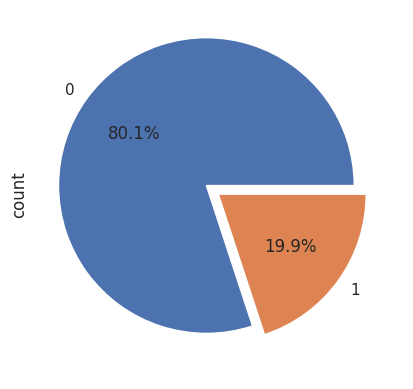

In [17]:
# How many defaulters
perc_default = data['BAD'].value_counts() / len(data['BAD'])
print(f'The percentage of defaulters in the data is {perc_default*100} %')
data['BAD'].value_counts().plot(kind='pie',explode=[0.1,0],autopct="%1.1f%%")
plt.plot()

**Observations:**
* 20% of the clients in the dataset are defaulter on their loans (BAD=1).
* 80% of the clients have successfully repaid their loans or are not defaulter (BAD=0).

**Categorical Columns**

In [18]:
def show_value_counts(col):
    print(col)
    value_counts = data[col].value_counts()
    percentage = value_counts / len(data) * 100
    result_df = pd.DataFrame({'Value': value_counts.index, 'Count': value_counts, 'Percentage': percentage})
    result_df = result_df.sort_values(by='Value')
    print(result_df)
    print('--------------------------')
    generate_pie_plot(result_df)


def generate_pie_plot(data_frame):
    plt.figure(figsize=(6, 5))
    plt.pie(data_frame['Count'], labels=data_frame['Value'], autopct='%1.1f%%')
    plt.axis('equal')
    plt.show()


REASON
           Value  Count  Percentage
REASON                             
DebtCon  DebtCon   3928   65.906040
HomeImp  HomeImp   1780   29.865772
--------------------------


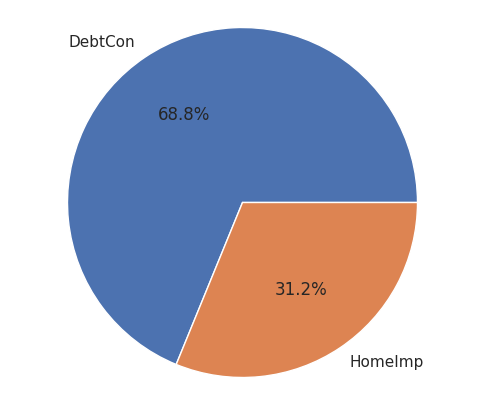

In [19]:
#Show unique categories in the REASON variable
show_value_counts('REASON')

**Observations:**

* Majority of clients (around 69.8%) have taken out loans for debt consolidation (DebtCon), indicating a higher frequency.

* Smaller portion of clients (around 30.2%) have taken out loans for home improvement purposes (HomeImp).

JOB
           Value  Count  Percentage
JOB                                
Mgr          Mgr    767   12.869128
Office    Office    948   15.906040
Other      Other   2388   40.067114
ProfExe  ProfExe   1276   21.409396
Sales      Sales    109    1.828859
Self        Self    193    3.238255
--------------------------


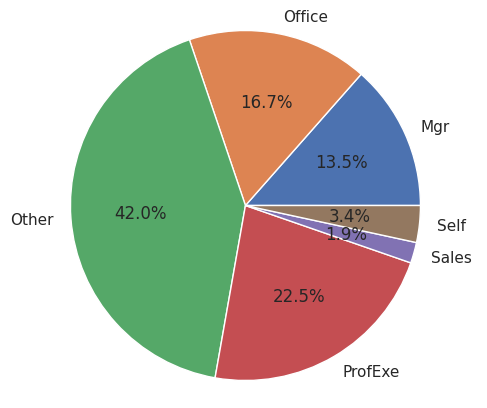

In [20]:
#Show unique categories in the JOB variable
show_value_counts('JOB')

**Observations:**
* Maximum number of clients mentioned their job category is "Other" (around 44.7%). This category likely includes diverse job roles not covered by the specific categories.
* "ProfExe" (Professional/Executive) most common job category, approximately 21.4% of the clients.
* "Office" job category around 15.8% of clients.
* "Mgr" (Manager), "Self" (Self-Employed), and "Sales" job categories have relatively smaller representations, with approximately 12.9%, 3.2%, and 1.8% of clients, respectively.

LOAN
Skew : 2.02


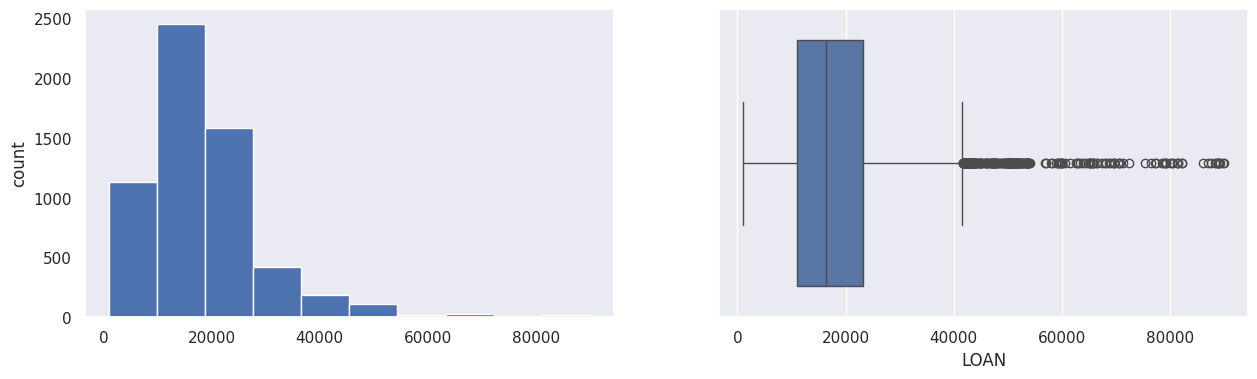

MORTDUE
Skew : 1.81


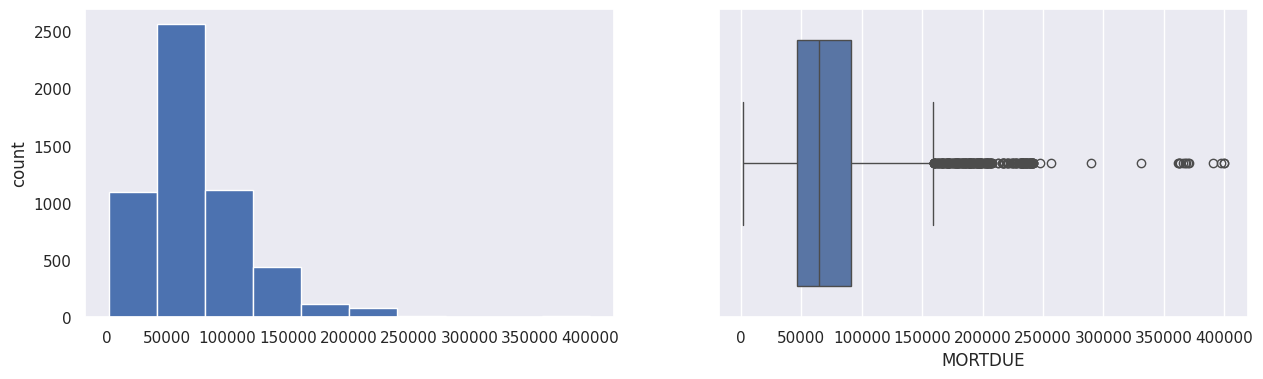

VALUE
Skew : 3.05


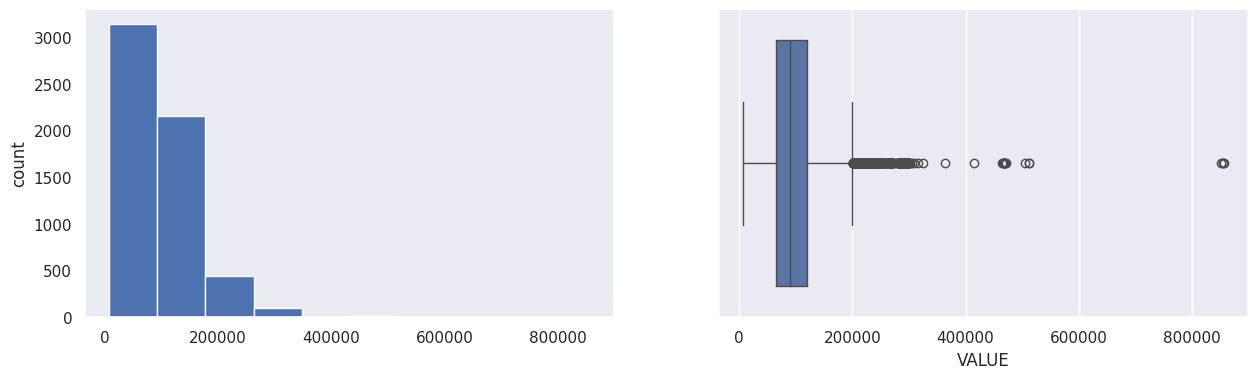

YOJ
Skew : 0.99


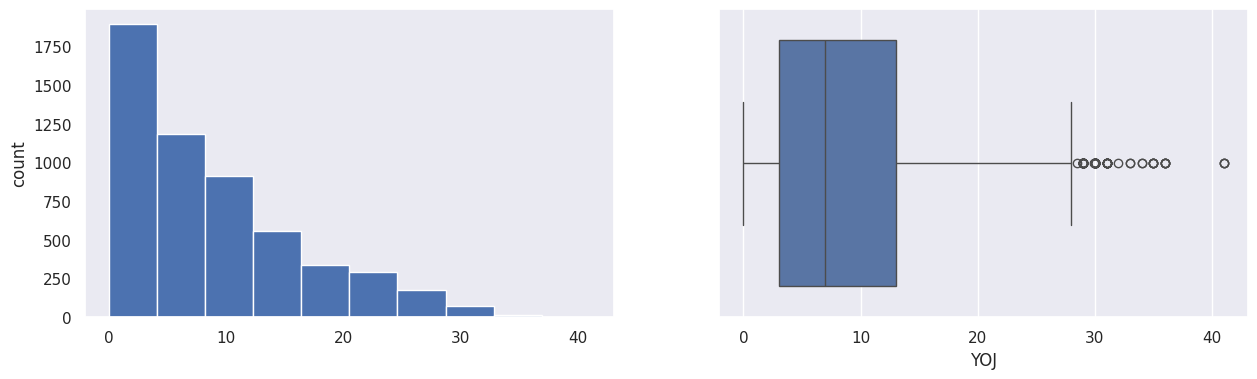

DEROG
Skew : 5.32


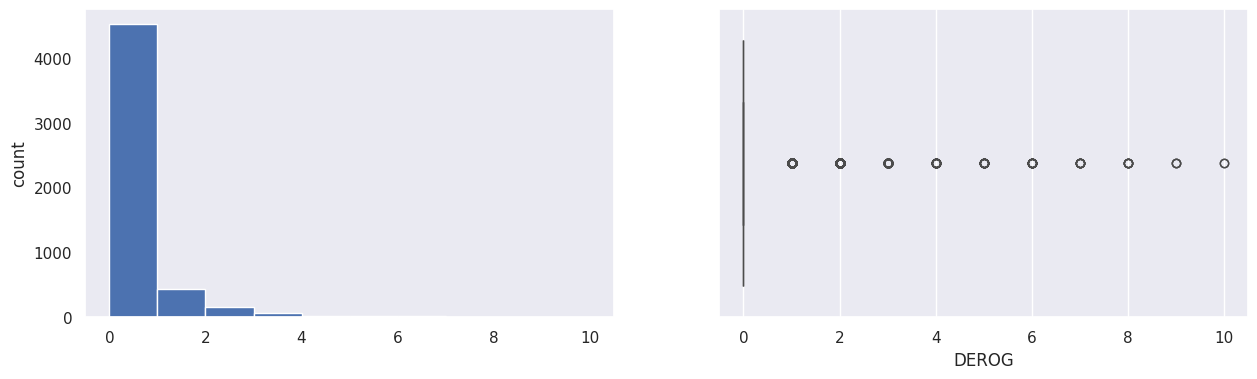

DELINQ
Skew : 4.02


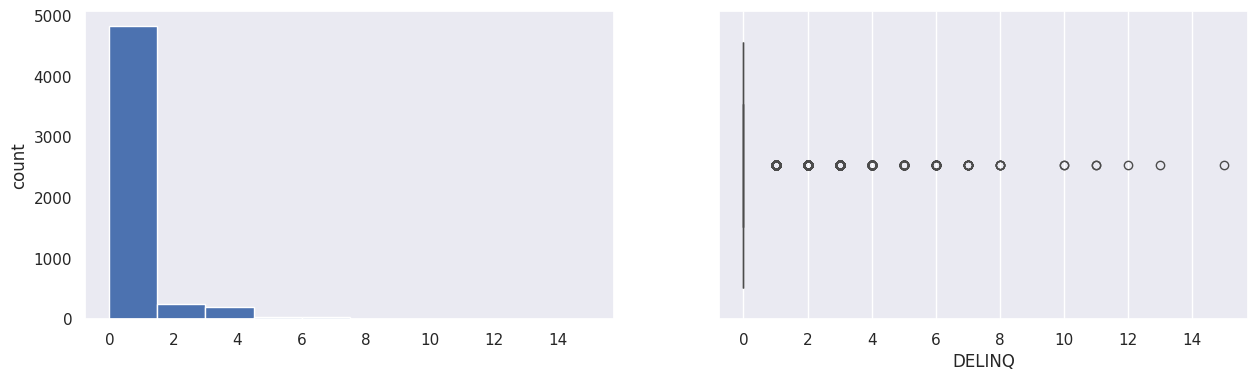

CLAGE
Skew : 1.34


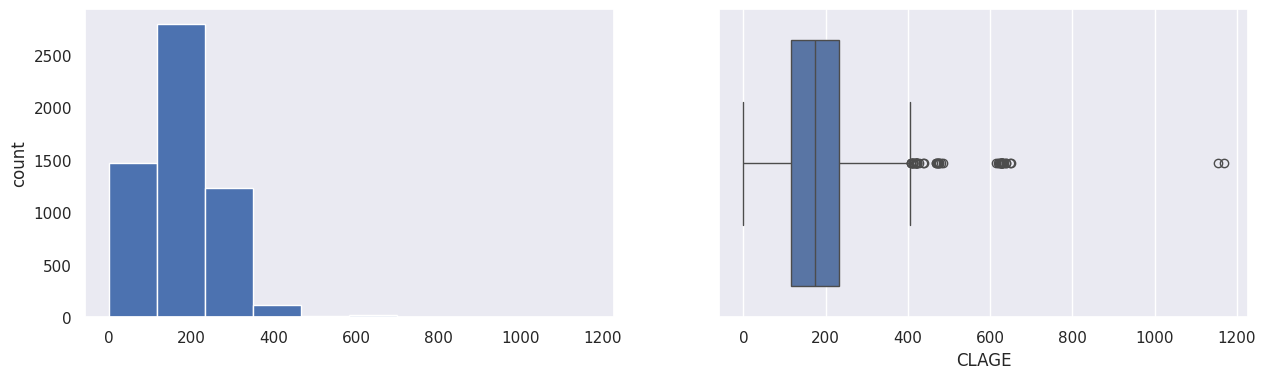

NINQ
Skew : 2.62


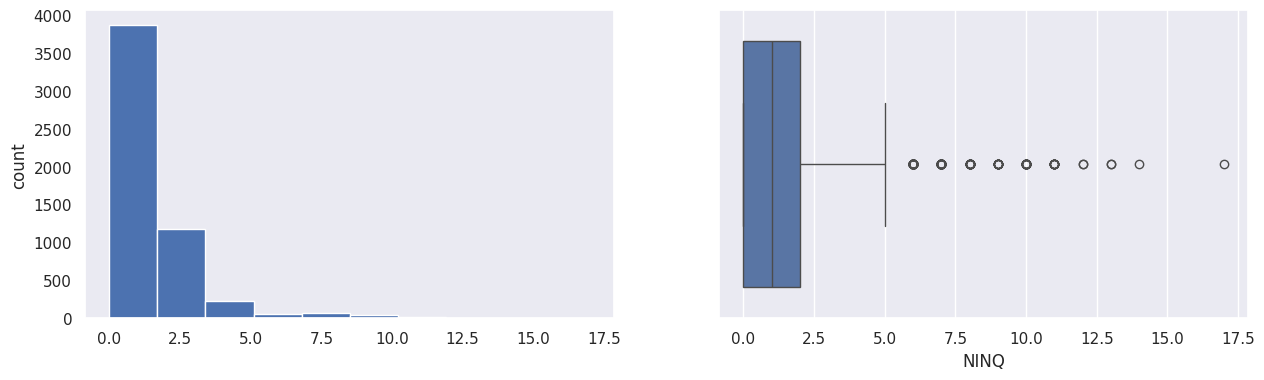

CLNO
Skew : 0.78


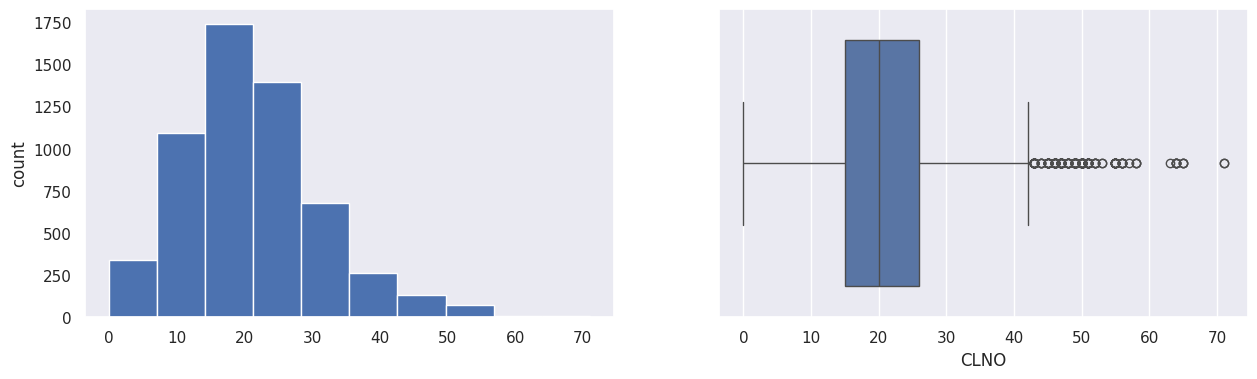

DEBTINC
Skew : 2.85


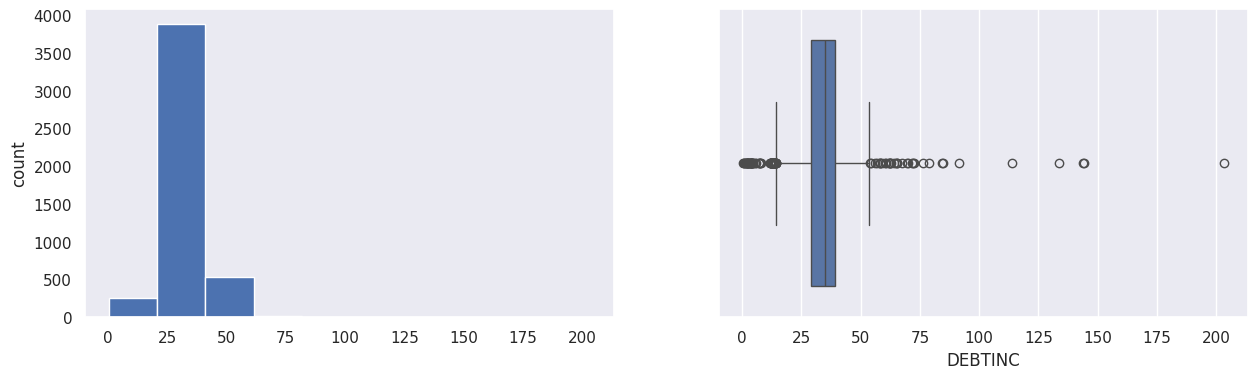

In [21]:
#histogram and boxplot of numerical variables
for feature in num_cols:
    print(feature)

    print('Skew :',round(data[feature].skew(), 2))

    plt.figure(figsize = (15, 4))

    plt.subplot(1, 2, 1)

    data[feature].hist(bins = 10, grid = False)

    plt.ylabel('count')

    plt.subplot(1, 2, 2)

    sns.boxplot(x = data[feature])

    plt.show()

**Observations:**

* LOAN, MORTDUE, VALUE, CLNO, DEBTINC variables have outliers.
* DEBTINC normal shape distribution that shows outliers on the right and left ends.
* The variable LOAN has a skewed distribution to the right with lot of big outliers compared to the mean.
* The variable YOG is very skewed to the right and has a few outliers.

### **Bivariate Analysis**

Bivariate Analysis: Continuous and Categorical Variables

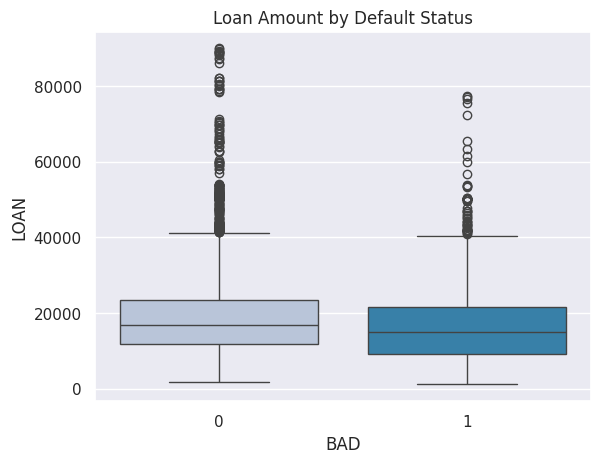

In [22]:
#Analyze BAD vs Loan
sns.boxplot(x=data["BAD"],y=data['LOAN'],palette="PuBu")
plt.title('Loan Amount by Default Status')
plt.show()

**Insight:**
- it seems that the two types of client (defaulted or not) receive the similar amount of loans

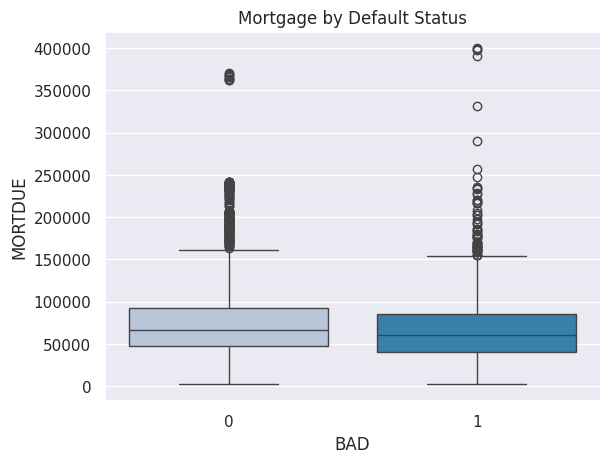

In [23]:
#Analyze BAD vs MORTDUE
sns.boxplot(x=data["BAD"],y=data['MORTDUE'],palette="PuBu")
plt.title('Mortgage by Default Status')
plt.show()

insights:
- Both types of clients (defaulted or not) have similar amount due on the existing mortgage.

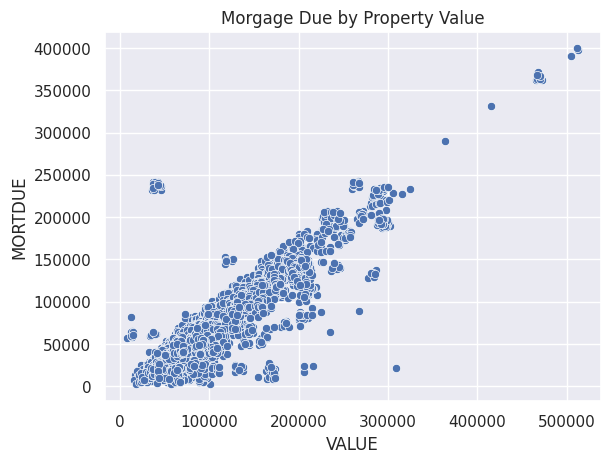

In [24]:
#scatterplot VALUE vs MORTDUE
sns.scatterplot(x=data["VALUE"],y=data['MORTDUE'],palette="PuBu")
plt.title('Morgage Due by Property Value')
plt.show()

**Insights:**

There is a linear correlation between the variables VALUE and MORTDUE.

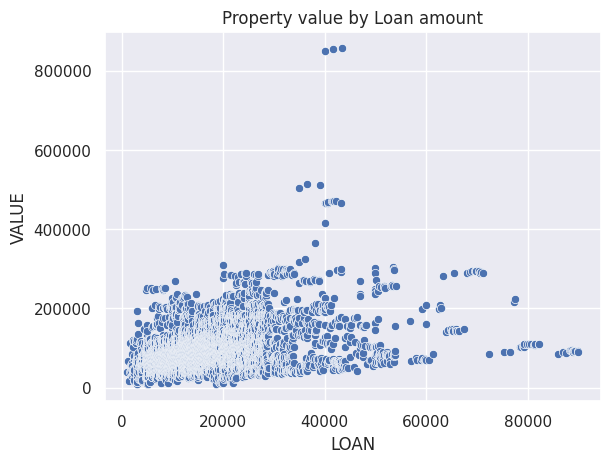

In [25]:
#scatterplot VALUE vs LOAN
sns.scatterplot(x=data["LOAN"],y=data['VALUE'],palette="PuBu")
plt.title('Property value by Loan amount')
plt.show()

**Insights:**

There is a no correlation between the value of the property and the loan default rate.

In [26]:
### Function to plot stacked bar charts for categorical columns
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.xticks(rotation=0)
    plt.show()

BAD         0     1   All
REASON                   
All      4567  1141  5708
DebtCon  3183   745  3928
HomeImp  1384   396  1780
------------------------------------------------------------------------------------------------------------------------


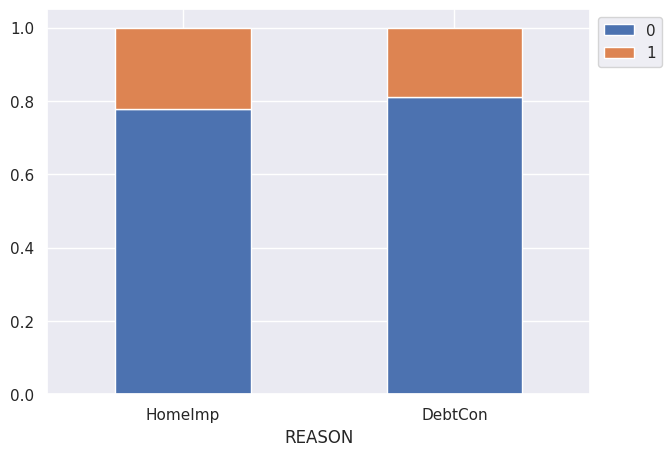

In [27]:
stacked_barplot(data, "REASON", "BAD")

**Observation:**
- Both reason debt consolidation or home improvement have no such difference on loan defaulter or not

**Debt Income Ratio vs default**

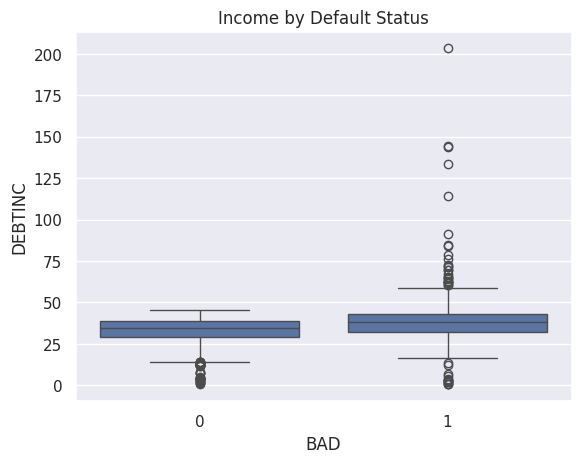

In [28]:
sns.boxplot(x='BAD', y='DEBTINC', data=data)
plt.title('Income by Default Status')
plt.show()

Insight:
- Borrowers with lower income levels appear more likely to default, suggesting income is an important risk predictor.
- This supports affordability assessment during loan approval.

**Credit history**

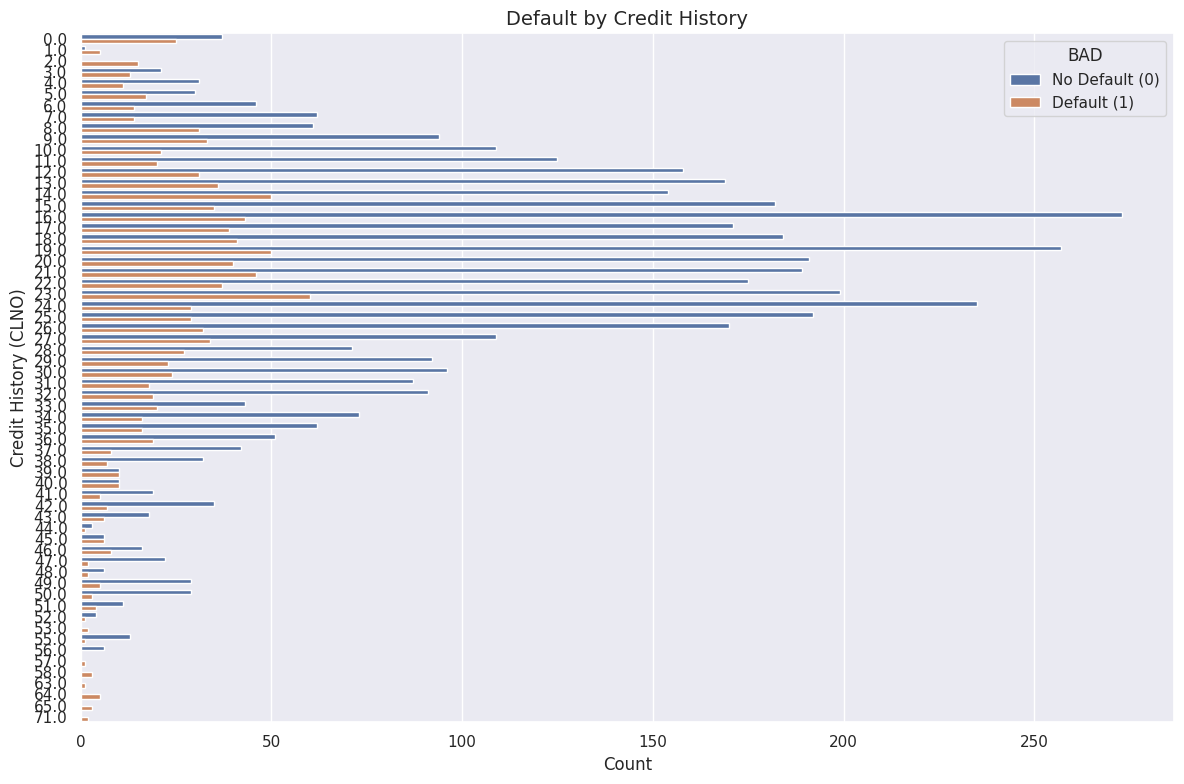

In [29]:
plt.figure(figsize=(12, 8))
sns.countplot(y='CLNO', hue='BAD', data=data, orient='h')
plt.title('Default by Credit History', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Credit History (CLNO)')
plt.legend(title='BAD', labels=['No Default (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

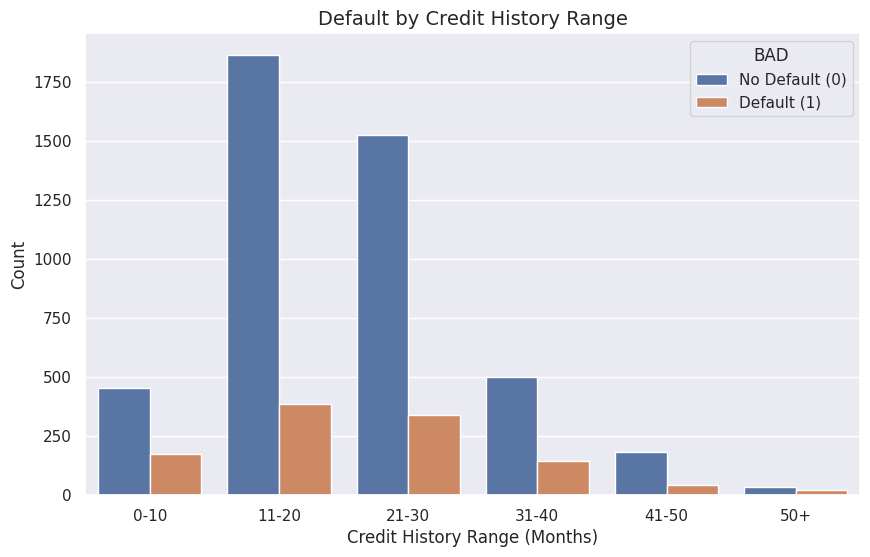

In [30]:
# Create bins for CLNO
data['CLNO_bins'] = pd.cut(data['CLNO'], bins=[0, 10, 20, 30, 40, 50, 100],
                         labels=['0-10', '11-20', '21-30', '31-40', '41-50', '50+'])

plt.figure(figsize=(10, 6))
sns.countplot(x='CLNO_bins', hue='BAD', data=data)
plt.title('Default by Credit History Range', fontsize=14)
plt.xlabel('Credit History Range (Months)')
plt.ylabel('Count')
plt.legend(title='BAD', labels=['No Default (0)', 'Default (1)'])
plt.show()

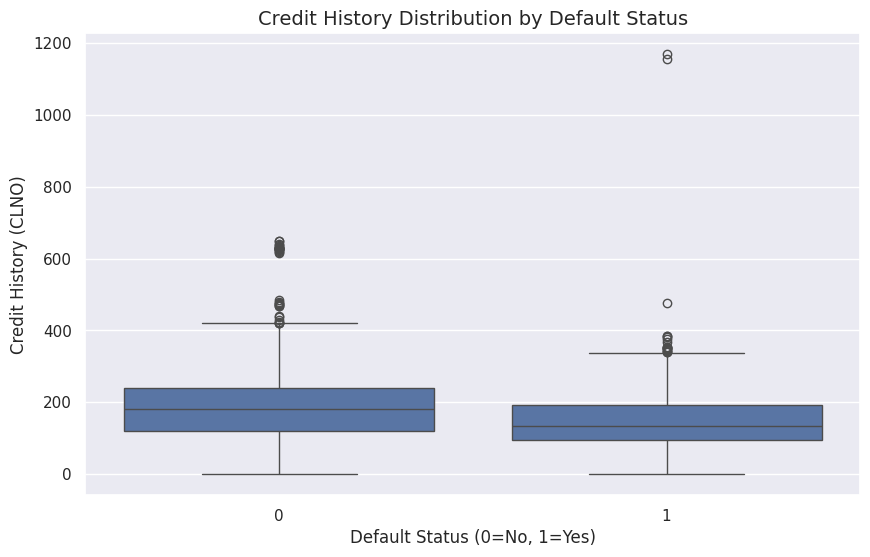

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='BAD', y='CLAGE', data=data)
plt.title('Credit History Distribution by Default Status', fontsize=14)
plt.xlabel('Default Status (0=No, 1=Yes)')
plt.ylabel('Credit History (CLNO)')
plt.show()

**Insight:**
- Borrowers with weak credit history demonstrate significantly higher default rates.

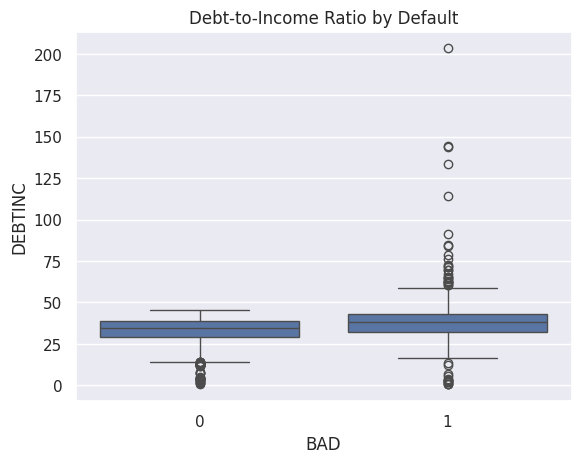

In [32]:
sns.boxplot(x='BAD', y='DEBTINC', data=data)
plt.title('Debt-to-Income Ratio by Default')
plt.show()

### **Multivariate Analysis**

Analyze Correlation Heatmap for Numerical Variables

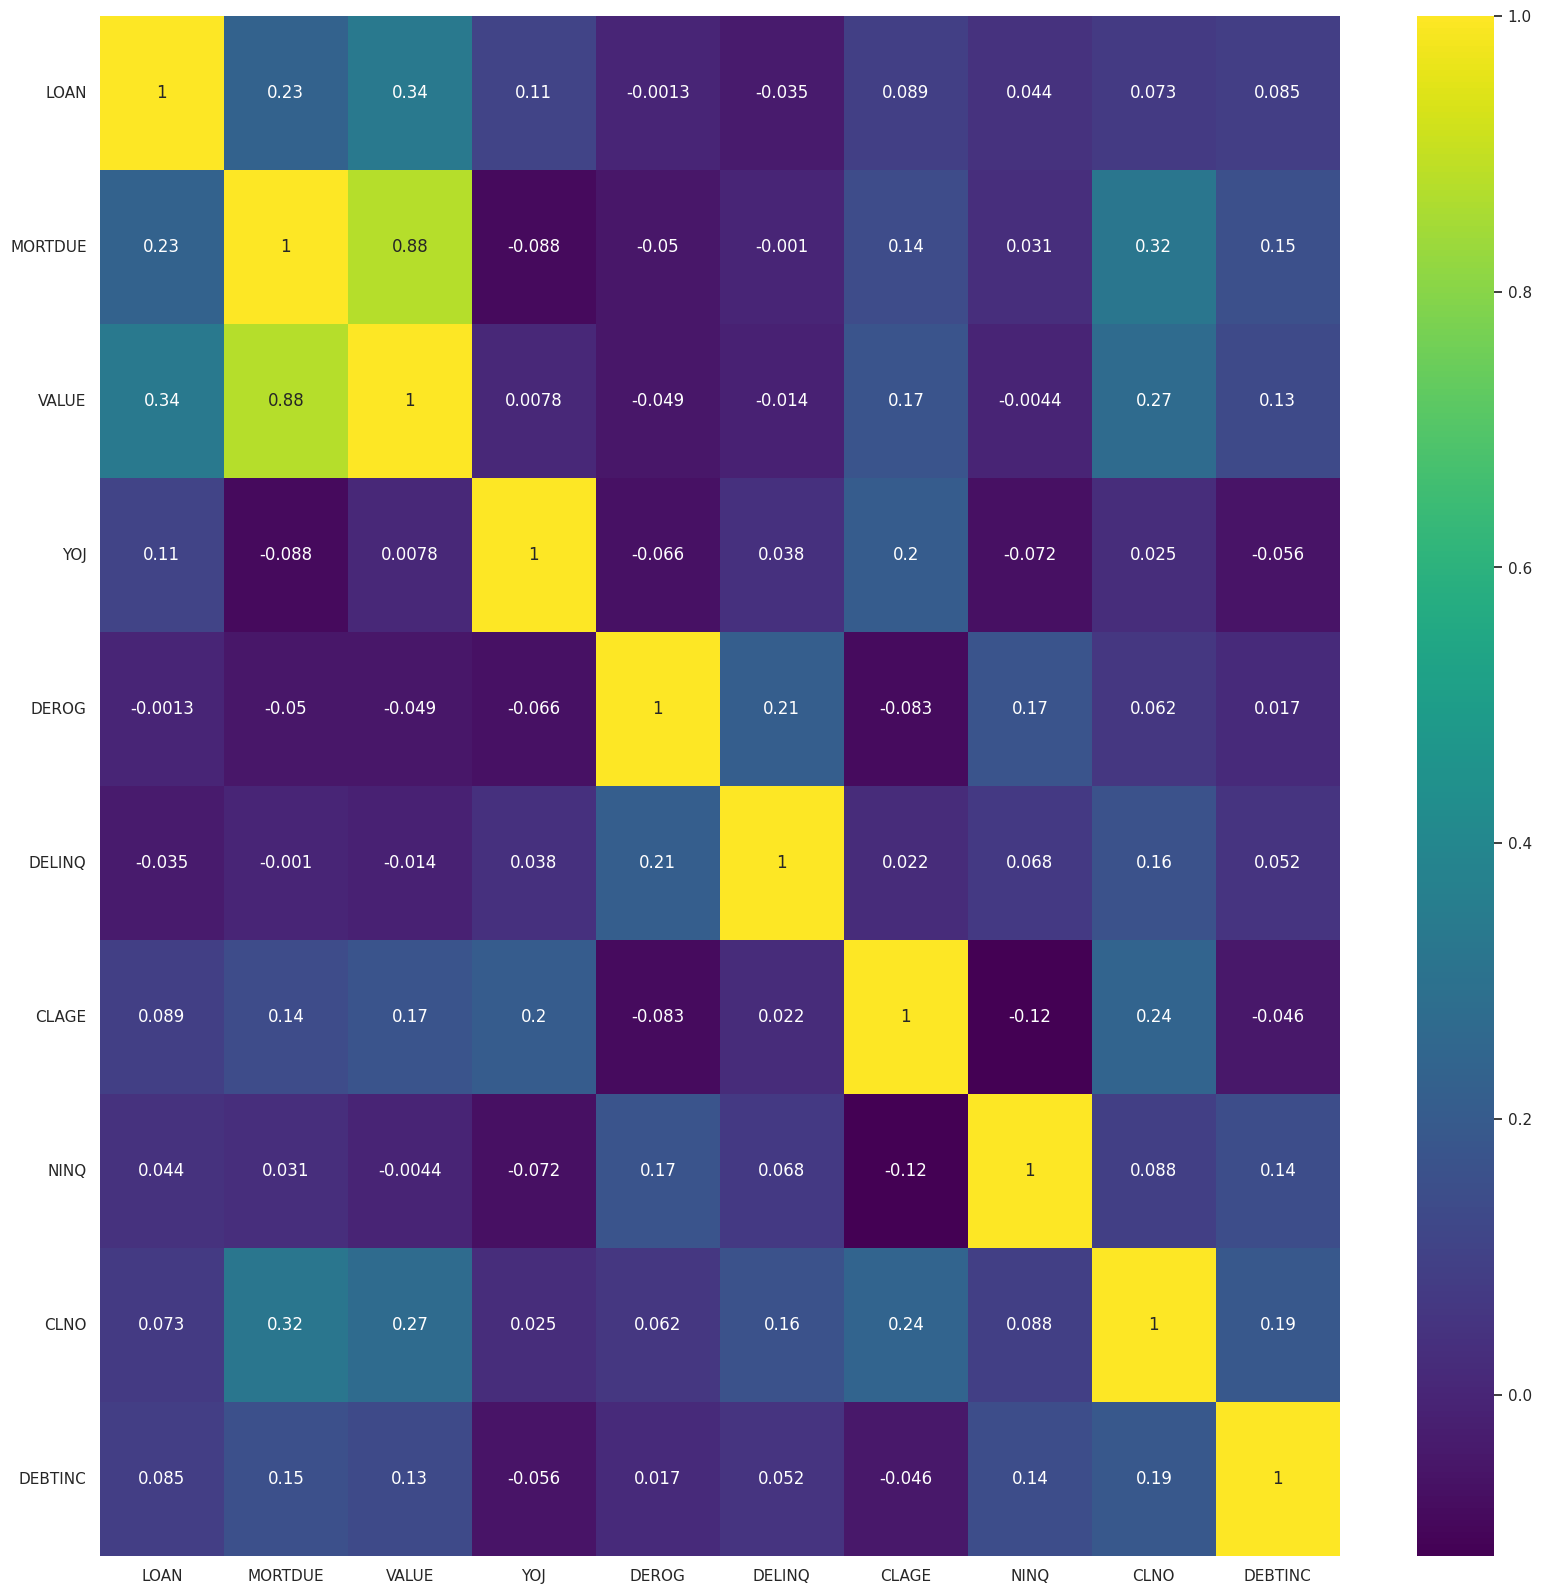

In [33]:
# Create a figure and plot the heatmap
plt.figure(figsize=(20, 20))
heat_map = sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="viridis")
heat_map.set_yticklabels(heat_map.get_yticklabels(), rotation=0)
plt.show()


## Treating Outliers

In [34]:
#function to treat outliers
def treat_outliers(df,col):
    '''
    treats outliers in a varaible
    col: str, name of the numerical varaible
    df: data frame

    '''

    Q1=df[col].quantile(q = .25) # 25th quantile
    Q3=df[col].quantile(q = .75)  # 75th quantile
    IQR = Q3-Q1   # IQR Range
    Lower_Whisker = Q1 - 1.5*IQR  #define lower whisker
    Upper_Whisker = Q3 + 1.5*IQR  # define upper Whisker
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker) # all the values samller than Lower_Whisker will be assigned value of Lower_whisker
                                                            # and all the values above upper_whishker will be assigned value of upper_Whisker
    return df

def treat_outliers_all(df, col_list):
    '''
    treat outlier in all numerical varaibles
    col_list: list of numerical varaibles
    df: data frame
    '''
    for c in col_list:
        df = treat_outliers(df,c)

    return df


In [35]:
#copy data
df_raw = data.copy()

numerical_col = df_raw.select_dtypes(include=np.number).columns.tolist()# getting list of numerical columns

df = treat_outliers_all(df_raw,numerical_col)

In [36]:
df

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,CLNO_bins
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,0-10
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,0.0,121.833333,0.0,14.0,NaN,11-20
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,0-10
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,11-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,41600,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,11-20
5956,0,41600,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,11-20
5957,0,41600,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,11-20
5958,0,41600,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,11-20


## Treating Missing Values

**Adding new columns in the dataset for each column which has missing values**

In [37]:
#For each column we create a binary flag for the row, if there is missing value in the row, then 1 else 0.
def add_binary_flag(df,col):
    '''
    df: It is the dataframe
    col: it is column which has missing values
    It returns a dataframe which has binary falg for missing values in column col
    '''
    new_col = str(col)
    new_col += '_missing_values_flag'
    df[new_col] = df[col].isna().astype(int)
    return df

In [38]:
# list of columns that has missing values in it
missing_col = [col for col in df.columns if df[col].isnull().any()]

for colmn in missing_col:
    add_binary_flag(df,colmn)




**Filling missing values in numerical columns with median and mode in categorical variables**

In [39]:
#  Treating Missing values in numerical columns with median and mode in categorical variables
# Select numeric columns.
num_data = df.select_dtypes('number')

# Selecting string and object columns.
cat_data = df.select_dtypes('category').columns.tolist() #df.select_dtypes('object')

# Filling numeric columns with median.
df[num_data.columns] = num_data.fillna(num_data.median())

# Filling object columns with mode.
for column in cat_data:
    mode = df[column].mode()[0]
    df[column].fillna(df[column].mode()[0], inplace=True)

## **Important Insights from EDA**

In [40]:
df.isnull().sum()

,0
BAD,0
LOAN,0
MORTDUE,0
VALUE,0
REASON,0
JOB,0
YOJ,0
DEROG,0
DELINQ,0
CLAGE,0


In [41]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,...,REASON_missing_values_flag,JOB_missing_values_flag,YOJ_missing_values_flag,DEROG_missing_values_flag,DELINQ_missing_values_flag,CLAGE_missing_values_flag,NINQ_missing_values_flag,CLNO_missing_values_flag,DEBTINC_missing_values_flag,CLNO_bins_missing_values_flag
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,...,0,0,0,0,0,0,0,0,1,0
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,0.0,121.833333,...,0,0,0,0,0,0,0,0,1,0
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,...,0,0,0,0,0,0,0,0,1,0
3,1,1500,65019.0,89235.5,DebtCon,Other,7.0,0.0,0.0,173.466667,...,1,1,1,1,1,1,1,1,1,1
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,...,0,0,0,0,0,0,0,0,1,0


In [42]:
df.tail()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,...,REASON_missing_values_flag,JOB_missing_values_flag,YOJ_missing_values_flag,DEROG_missing_values_flag,DELINQ_missing_values_flag,CLAGE_missing_values_flag,NINQ_missing_values_flag,CLNO_missing_values_flag,DEBTINC_missing_values_flag,CLNO_bins_missing_values_flag
5955,0,41600,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,...,0,0,0,0,0,0,0,0,0,0
5956,0,41600,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,...,0,0,0,0,0,0,0,0,0,0
5957,0,41600,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,...,0,0,0,0,0,0,0,0,0,0
5958,0,41600,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,...,0,0,0,0,0,0,0,0,0,0
5959,0,41600,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,...,0,0,0,0,0,0,0,0,0,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   BAD                            5960 non-null   category
 1   LOAN                           5960 non-null   int64   
 2   MORTDUE                        5960 non-null   float64 
 3   VALUE                          5960 non-null   float64 
 4   REASON                         5960 non-null   category
 5   JOB                            5960 non-null   category
 6   YOJ                            5960 non-null   float64 
 7   DEROG                          5960 non-null   float64 
 8   DELINQ                         5960 non-null   float64 
 9   CLAGE                          5960 non-null   float64 
 10  NINQ                           5960 non-null   float64 
 11  CLNO                           5960 non-null   float64 
 12  DEBTINC                        596

**Droping missing value flags**

In [44]:
#creating a list of bool features
bool_cols = df.select_dtypes(['bool']).columns.tolist()

#droping missing value flags
X = df.drop(columns = bool_cols)

In [45]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   BAD                            5960 non-null   category
 1   LOAN                           5960 non-null   int64   
 2   MORTDUE                        5960 non-null   float64 
 3   VALUE                          5960 non-null   float64 
 4   REASON                         5960 non-null   category
 5   JOB                            5960 non-null   category
 6   YOJ                            5960 non-null   float64 
 7   DEROG                          5960 non-null   float64 
 8   DELINQ                         5960 non-null   float64 
 9   CLAGE                          5960 non-null   float64 
 10  NINQ                           5960 non-null   float64 
 11  CLNO                           5960 non-null   float64 
 12  DEBTINC                        596

## **Model Building - Approach**


## **Data Preparation**

**Separating the target variable from other variables**

In [46]:
# Separating the target variable and other variables
Y = X.BAD
X = X.drop(columns = ['BAD','CLNO_bins'])

# Creating dummy variables for the categorical variables

# Creating the list of columns for which we need to create the dummy variables
to_get_dummies_for = ['REASON', 'JOB']

# Creating dummy variables
X = pd.get_dummies(data = X, columns = to_get_dummies_for, drop_first = True)

In [47]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   LOAN                           5960 non-null   int64  
 1   MORTDUE                        5960 non-null   float64
 2   VALUE                          5960 non-null   float64
 3   YOJ                            5960 non-null   float64
 4   DEROG                          5960 non-null   float64
 5   DELINQ                         5960 non-null   float64
 6   CLAGE                          5960 non-null   float64
 7   NINQ                           5960 non-null   float64
 8   CLNO                           5960 non-null   float64
 9   DEBTINC                        5960 non-null   float64
 10  MORTDUE_missing_values_flag    5960 non-null   int64  
 11  VALUE_missing_values_flag      5960 non-null   int64  
 12  REASON_missing_values_flag     5960 non-null   i

In [48]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   LOAN                           5960 non-null   int64  
 1   MORTDUE                        5960 non-null   float64
 2   VALUE                          5960 non-null   float64
 3   YOJ                            5960 non-null   float64
 4   DEROG                          5960 non-null   float64
 5   DELINQ                         5960 non-null   float64
 6   CLAGE                          5960 non-null   float64
 7   NINQ                           5960 non-null   float64
 8   CLNO                           5960 non-null   float64
 9   DEBTINC                        5960 non-null   float64
 10  MORTDUE_missing_values_flag    5960 non-null   int64  
 11  VALUE_missing_values_flag      5960 non-null   int64  
 12  REASON_missing_values_flag     5960 non-null   i

## **Scaling the data**

In this case features have different scales, so we will use the Standard Scaler method, which centers and scales the dataset using the Z-Score.

In [49]:
# Scaling the data
sc = StandardScaler()

X_scaled = sc.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns = X.columns)

In [50]:
X_scaled

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,...,NINQ_missing_values_flag,CLNO_missing_values_flag,DEBTINC_missing_values_flag,CLNO_bins_missing_values_flag,REASON_HomeImp,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,-1.832283,-1.268083,-1.328686,0.251171,0.0,0.0,-1.071599,-0.065054,-1.297476,0.140949,...,-0.305905,-0.196696,1.924584,-0.223686,1.532421,-0.434909,1.111180,-0.521936,-0.136489,-0.182938
1,-1.810666,-0.026523,-0.670929,-0.240303,0.0,0.0,-0.721212,-0.826792,-0.756608,0.140949,...,-0.305905,-0.196696,1.924584,-0.223686,1.532421,-0.434909,1.111180,-0.521936,-0.136489,-0.182938
2,-1.789048,-1.615326,-1.828581,-0.661566,0.0,0.0,-0.368698,-0.065054,-1.189302,0.140949,...,-0.305905,-0.196696,1.924584,-0.223686,1.532421,-0.434909,1.111180,-0.521936,-0.136489,-0.182938
3,-1.789048,-0.167948,-0.204386,-0.240303,0.0,0.0,-0.062534,-0.065054,-0.107566,0.140949,...,3.268987,5.083979,1.924584,4.470561,-0.652562,-0.434909,1.111180,-0.521936,-0.136489,-0.182938
4,-1.767431,0.753003,0.305350,-0.801987,0.0,0.0,-1.084781,-0.826792,-0.756608,0.140949,...,-0.305905,-0.196696,1.924584,-0.223686,1.532421,2.299330,-0.899944,-0.521936,-0.136489,-0.182938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,2.545249,-0.385818,-0.183125,1.023488,0.0,0.0,0.554157,-0.826792,-0.540260,0.344808,...,-0.305905,-0.196696,-0.519593,-0.223686,-0.652562,-0.434909,1.111180,-0.521936,-0.136489,-0.182938
5956,2.545249,-0.461334,-0.121503,1.023488,0.0,0.0,0.386830,-0.826792,-0.648434,0.305051,...,-0.305905,-0.196696,-0.519593,-0.223686,-0.652562,-0.434909,1.111180,-0.521936,-0.136489,-0.182938
5957,2.545249,-0.476252,-0.121794,0.883067,0.0,0.0,0.432597,-0.826792,-0.648434,0.257259,...,-0.305905,-0.196696,-0.519593,-0.223686,-0.652562,-0.434909,1.111180,-0.521936,-0.136489,-0.182938
5958,2.545249,-0.579498,-0.145596,0.742645,0.0,0.0,0.453174,-0.826792,-0.540260,0.065746,...,-0.305905,-0.196696,-0.519593,-0.223686,-0.652562,-0.434909,1.111180,-0.521936,-0.136489,-0.182938


**Splitting the data into 70% train and 30% test set**

The data is unbalanced (~80% is non defaulted and ~20% is defaulted). For this reason, we will use stratified sampling technique to ensure that relative class frequencies are approximately preserved in each train and validation fold.

In [51]:
# Splitting the data into training and test set

x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size = 0.3, random_state = 1, stratify = Y)

## Model Evaluation Criterion

In [52]:
#creating metric function
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)

    group_names = ['True Neg','False Pos','False Neg','True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in
                    cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=labels, fmt='', xticklabels=['Not Eligible', 'Eligible'], yticklabels=['Not Eligible', 'Eligible'],cmap='Blues')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [53]:
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance
    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # Predicting using the independent variables
    pred = model.predict(predictors)
    recall = recall_score(target, pred,average = 'macro')                 # To compute recall
    precision = precision_score(target, pred, average = 'macro')              # To compute precision
    acc = accuracy_score(target, pred)                                 # To compute accuracy score

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Precision":  precision,
            "Recall":  recall,
            "Accuracy": acc,
        },

        index = [0],
    )

    return df_perf

### Logistic Regression

Logistic Regression is a supervised learning algorithm, generally used for binary classification problems, i.e., where the dependent variable is categorical and has only two possible values. In logistic regression, we use the sigmoid function to calculate the probability of an event Y, given some features X as:

                                    P(Y)=1/(1 + exp(-X))

In [54]:
# Defining the Logistic regression model
lg = LogisticRegression()

# Fitting the model on the training data
lg.fit(x_train,y_train)

LogisticRegression()

### Checking the performance on the train dataset

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3340
           1       0.72      0.61      0.66       832

    accuracy                           0.87      4172
   macro avg       0.81      0.77      0.79      4172
weighted avg       0.87      0.87      0.87      4172



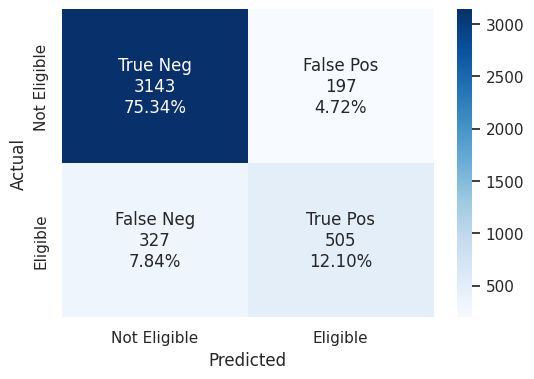

In [55]:
#Predicting for train set
y_pred_train = lg.predict(x_train)

#checking the performance on the train dataset
metrics_score(y_train, y_pred_train)

Checking the performance on the test dataset

              precision    recall  f1-score   support

           0       0.90      0.95      0.93      1431
           1       0.74      0.59      0.66       357

    accuracy                           0.88      1788
   macro avg       0.82      0.77      0.79      1788
weighted avg       0.87      0.88      0.87      1788



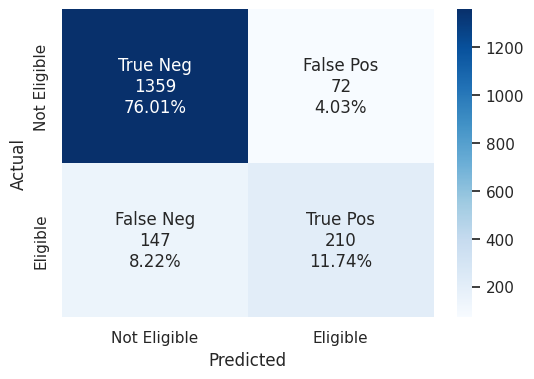

In [56]:
#Predicting for test set
y_pred_test = lg.predict(x_test)

#checking the performance on the test dataset
metrics_score(y_test, y_pred_test)

In [57]:
lg_test = model_performance_classification(lg,x_test,y_test)
lg_test

,Precision,Recall,Accuracy
0,0.823536,0.76896,0.877517


Let's check the coefficients, and check which variables are important and how they affect the process of loan approval

In [58]:
# Printing the coefficients of logistic regression

cols = X_scaled.columns

coef_lg = lg.coef_

pd.DataFrame(coef_lg,columns = cols).T.sort_values(by = 0, ascending = False)

,0
DEBTINC_missing_values_flag,1.160946
CLNO_bins_missing_values_flag,0.880856
VALUE_missing_values_flag,0.739030
DEBTINC,0.682881
NINQ,0.199338
MORTDUE_missing_values_flag,0.163818
CLNO_missing_values_flag,0.149049
REASON_HomeImp,0.117100
JOB_Sales,0.110078
VALUE,0.097099


**Insights:**

Features which positively affect on the defaulted rate are:

* DEBTINC
* NINQ

Features which negatively affect on the defaulted rate are:

* MORTDUE
* CLAGE
The coefficients of the logistic regression model give us the log of odds, which is hard to interpret in the real world. We can convert the log of odds into odds by taking its exponential.

In [59]:
odds = np.exp(lg.coef_[0]) # Finding the odds

# Adding the odds to a DataFrame and sorting the values
pd.DataFrame(odds, x_train.columns, columns = ['odds']).sort_values(by = 'odds', ascending = False)

,odds
DEBTINC_missing_values_flag,3.192953
CLNO_bins_missing_values_flag,2.412964
VALUE_missing_values_flag,2.093903
DEBTINC,1.979572
NINQ,1.220595
MORTDUE_missing_values_flag,1.177999
CLNO_missing_values_flag,1.160730
REASON_HomeImp,1.124231
JOB_Sales,1.116365
VALUE,1.101969


* The odds of defaulting for a client with high debt/income ratio is 50% higher than one with low ratio.
* The odds of defaulting for a client with many recent credit inquiries is ~34% higher than one with a small number.

**The Precision-Recall Curve for Logistic Regression**

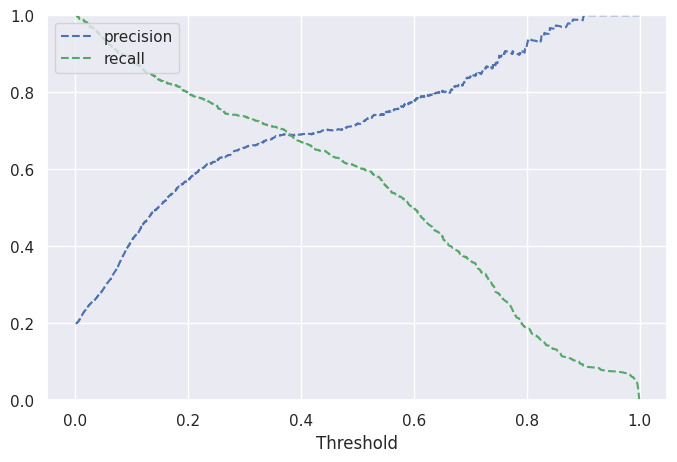

In [60]:
y_scores_lg = lg.predict_proba(x_train) # predict_proba gives the probability of each observation belonging to each class


precisions_lg, recalls_lg, thresholds_lg = precision_recall_curve(y_train, y_scores_lg[:, 1])

# Plot values of precisions, recalls, and thresholds
plt.figure(figsize = (8,5))

plt.plot(thresholds_lg, precisions_lg[:-1], 'b--', label = 'precision')

plt.plot(thresholds_lg, recalls_lg[:-1], 'g--', label = 'recall')

plt.xlabel('Threshold')

plt.legend(loc = 'upper left')

plt.ylim([0, 1])

plt.show()

**Observation:**

We can see that the precision and the recall are balanced for a threshold of about 0.28.

**Let's find out the performance of the model at this threshold.**

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      3340
           1       0.65      0.74      0.69       832

    accuracy                           0.87      4172
   macro avg       0.79      0.82      0.80      4172
weighted avg       0.88      0.87      0.87      4172



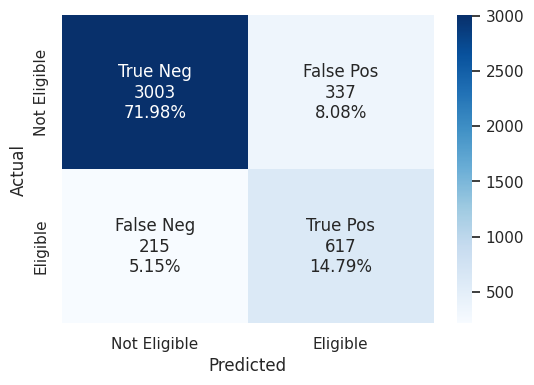

In [61]:
optimal_threshold1 = .28

y_pred_train = lg.predict_proba(x_train)

metrics_score(y_train, y_pred_train[:, 1] > optimal_threshold1)

**Observations:**

The model performance has improved. The recall has increased significantly for class 1 to 41%.

**Let's check the performance on the test data at threshold .28.**

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1431
           1       0.67      0.73      0.70       357

    accuracy                           0.87      1788
   macro avg       0.80      0.82      0.81      1788
weighted avg       0.88      0.87      0.88      1788



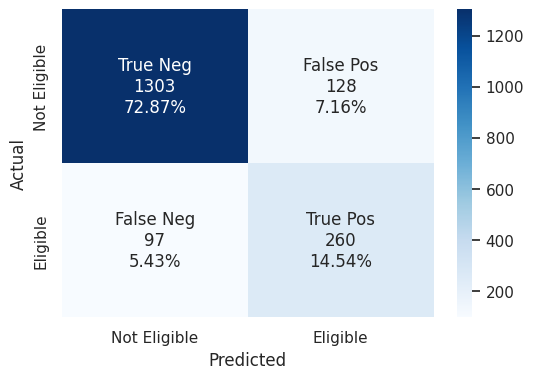

In [62]:
optimal_threshold1 = .28

y_pred_test = lg.predict_proba(x_test)

metrics_score(y_test, y_pred_test[:, 1] > optimal_threshold1)

**Observations:**

* The model is giving a similar performance on the test and the train datasets, i.e., the model is giving a generalized performance.
* The recall of the test data has increased to 41% while at the same time, the precision has decreased slightly, which is to be expected while adjusting the threshold.
* Nevertheless, Recall is still low.

### Decision Tree

**Data Preparation for the tree based model**

In [63]:
#copying df to another variable
data = df.copy()

Separating the target variable y and independent variable x

In [64]:
# Separating the target variable and other variables
Y = data.BAD
X = data.drop(columns = ['BAD', 'CLNO_bins'])

# Creating the list of columns for which we need to create the dummy variables
to_get_dummies_for = ['REASON', 'JOB']

# Creating dummy variables
X = pd.get_dummies(data = X, columns = to_get_dummies_for, drop_first = True)

In [65]:
X

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,...,NINQ_missing_values_flag,CLNO_missing_values_flag,DEBTINC_missing_values_flag,CLNO_bins_missing_values_flag,REASON_HomeImp,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,34.818262,...,0,0,1,0,True,False,True,False,False,False
1,1300,70053.0,68400.0,7.0,0.0,0.0,121.833333,0.0,14.0,34.818262,...,0,0,1,0,True,False,True,False,False,False
2,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,34.818262,...,0,0,1,0,True,False,True,False,False,False
3,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,1.0,20.0,34.818262,...,1,1,1,1,False,False,True,False,False,False
4,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.818262,...,0,0,1,0,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,41600,57264.0,90185.0,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,...,0,0,0,0,False,False,True,False,False,False
5956,41600,54576.0,92937.0,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,...,0,0,0,0,False,False,True,False,False,False
5957,41600,54045.0,92924.0,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,...,0,0,0,0,False,False,True,False,False,False
5958,41600,50370.0,91861.0,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,...,0,0,0,0,False,False,True,False,False,False


**Split the data**

In [66]:
# Split the data into training and test set (We use Stratify = 1 because data is unbalanced)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1, stratify = Y)

In [67]:
#Defining Decision tree model with class weights class_weight={0: 0.2, 1: 0.8}
dt = DecisionTreeClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state = 1)

In [68]:
#fitting Decision tree model
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

**Checking the performance on the train dataset**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



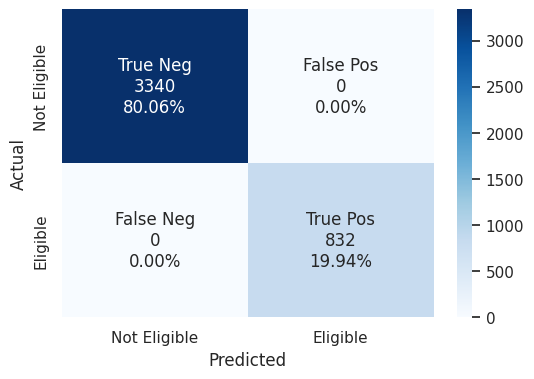

In [69]:
# Checking performance on the training data

y_train_pred_dt = dt.predict(x_train)

metrics_score(y_train, y_train_pred_dt)

**Checking the performance on the test dataset**

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1431
           1       0.64      0.58      0.61       357

    accuracy                           0.85      1788
   macro avg       0.77      0.75      0.76      1788
weighted avg       0.85      0.85      0.85      1788



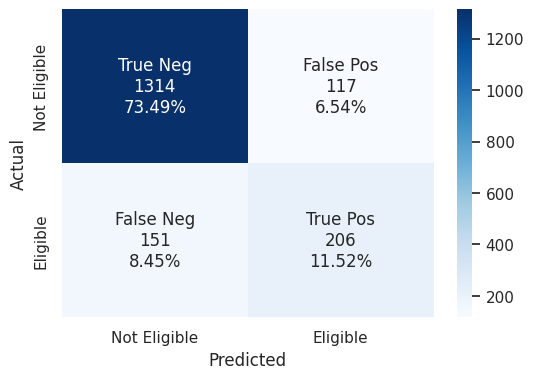

In [70]:
# Checking performance on the testing data

y_test_pred_dt = dt.predict(x_test)

metrics_score(y_test, y_test_pred_dt)

In [71]:
dtree = model_performance_classification(dt,x_test,y_test)
dtree

,Precision,Recall,Accuracy
0,0.76735,0.747635,0.850112


**Observations:**

* The Decision Tree works not so well on the test data as the recall is 0.59 in comparison to 1.00 for the training dataset, i.e., the Decision Tree is overfitting the training data.
* The precision on the test data suggests that there's a 34% chance that the model will predict that a client is going to default even though he/she would not (false positive), increasing the risk for the bank to loses income.
* The recall in this model is greater than in logistical regression.

Let's plot the feature importance and check the most important features.

<Axes: xlabel='Importance', ylabel='None'>

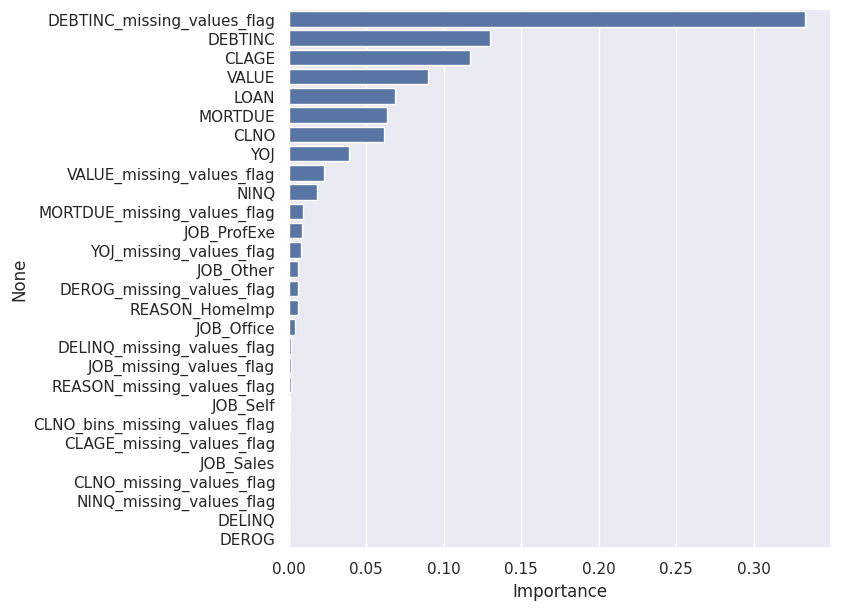

In [72]:
importances = dt.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (7, 7))
sns.barplot(x=importance_df.Importance, y=importance_df.index)

**Observations:**
* According to the Decision Tree, DEBTINC_missing_values_flag is the most important feature, followed by DEBTINC. This signifies that applicants who are at risk of default a loan have high debt and relatively low income
* The other important features CLNO, LOAN, CLAGE, VALUE, MORTDUE,CLNO.

### **Decision Tree - Hyperparameter Tuning**

* Hyperparameter tuning is tricky in the sense that there is no direct way to calculate how a change in the hyperparameter value will reduce the loss of the model.
* Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.
* It is an exhaustive search that is performed on the specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

**Hyperparameter tuning of Decision tree model Using GridSearchCV**

In [73]:
# Choosing the type of classifier.
d_tree_tuned = DecisionTreeClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state = 1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 7),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
gridCV = GridSearchCV(d_tree_tuned, parameters, scoring = scorer, cv = 10)


# Fitting the GridSearch on train dataset
gridCV = gridCV.fit(x_train, y_train)


# Setting the clf to the best combination of parameters
d_tree_tunedr = gridCV.best_estimator_


# Fitting the best algorithm to the data.
d_tree_tuned.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

**Checking the performance on the train dataset**


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



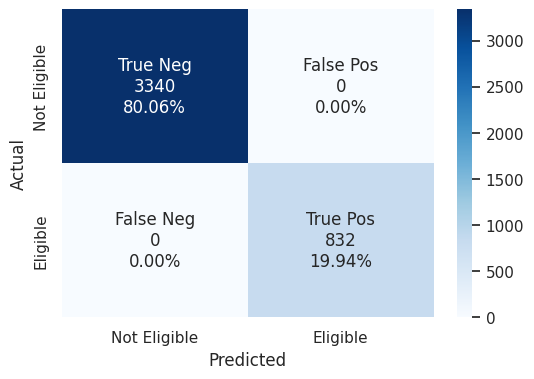

In [74]:
# Checking performance on the training data based on the tuned model

y_train_pred_dt = d_tree_tuned.predict(x_train)

metrics_score(y_train, y_train_pred_dt)

**Checking the performance on the test dataset**

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1431
           1       0.64      0.58      0.61       357

    accuracy                           0.85      1788
   macro avg       0.77      0.75      0.76      1788
weighted avg       0.85      0.85      0.85      1788



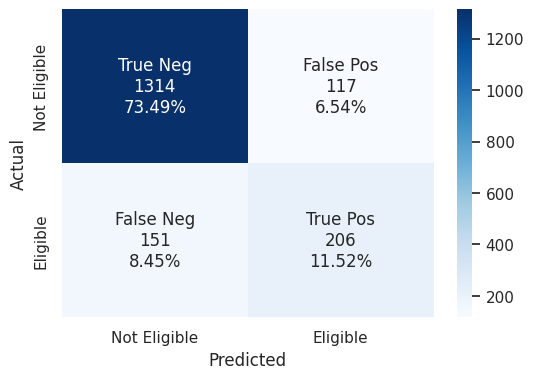

In [75]:
# Checking performance on the testing data based on the tuned model

y_test_pred_dt = d_tree_tuned.predict(x_test)

metrics_score(y_test, y_test_pred_dt)

In [76]:
dtree_tuned_test = model_performance_classification(d_tree_tuned,x_test,y_test)
dtree_tuned_test

,Precision,Recall,Accuracy
0,0.76735,0.747635,0.850112


**Observations:**

* In comparison to the model with default values of hyperparameters, the performance on the training set has gone down significantly (1.00 to 0.74) This makes sense because we are trying to reduce overfitting.
* The tuned model is performing well in comparison to the model with default values of hyperparameters: Recall increases from 0.61 to 0.74 in test data.
* This model is not overfitting the training data and giving approximately the same result on the test and train datasets.
* Precision has gone down significantly from .73 to .62 in comparison to the previous model which means the tuned model will give a high number of false positives, i.e., this model will predict the client is going to default even if he/she won't, and this will increases the risk of losing income.

Let's observe the feature importance of this model and try to analyze

<Axes: xlabel='Importance', ylabel='None'>

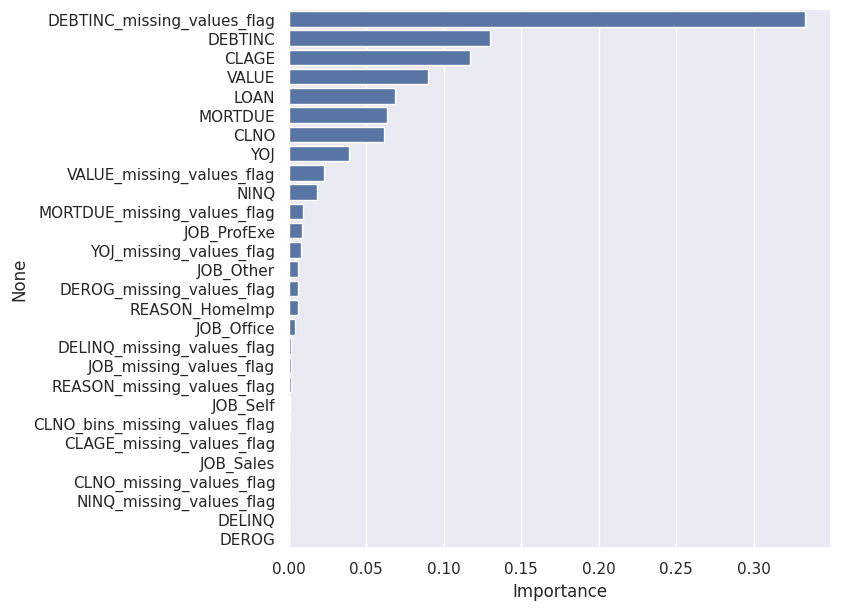

In [77]:
importances = d_tree_tuned.feature_importances_

columns = X.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (7, 7))

sns.barplot(x=importance_df.Importance,y= importance_df.index)

**Observations:**
* According to this model too, DEBTINC_missing_value, DEBTINC, DELINQ, CLAGE, DEROG, CLNO, MORTDUEand YOG are the most important features that describe why a client is defaulting.
* The tuned model is more generalized than the default model.

**Plotting the Decision Tree**

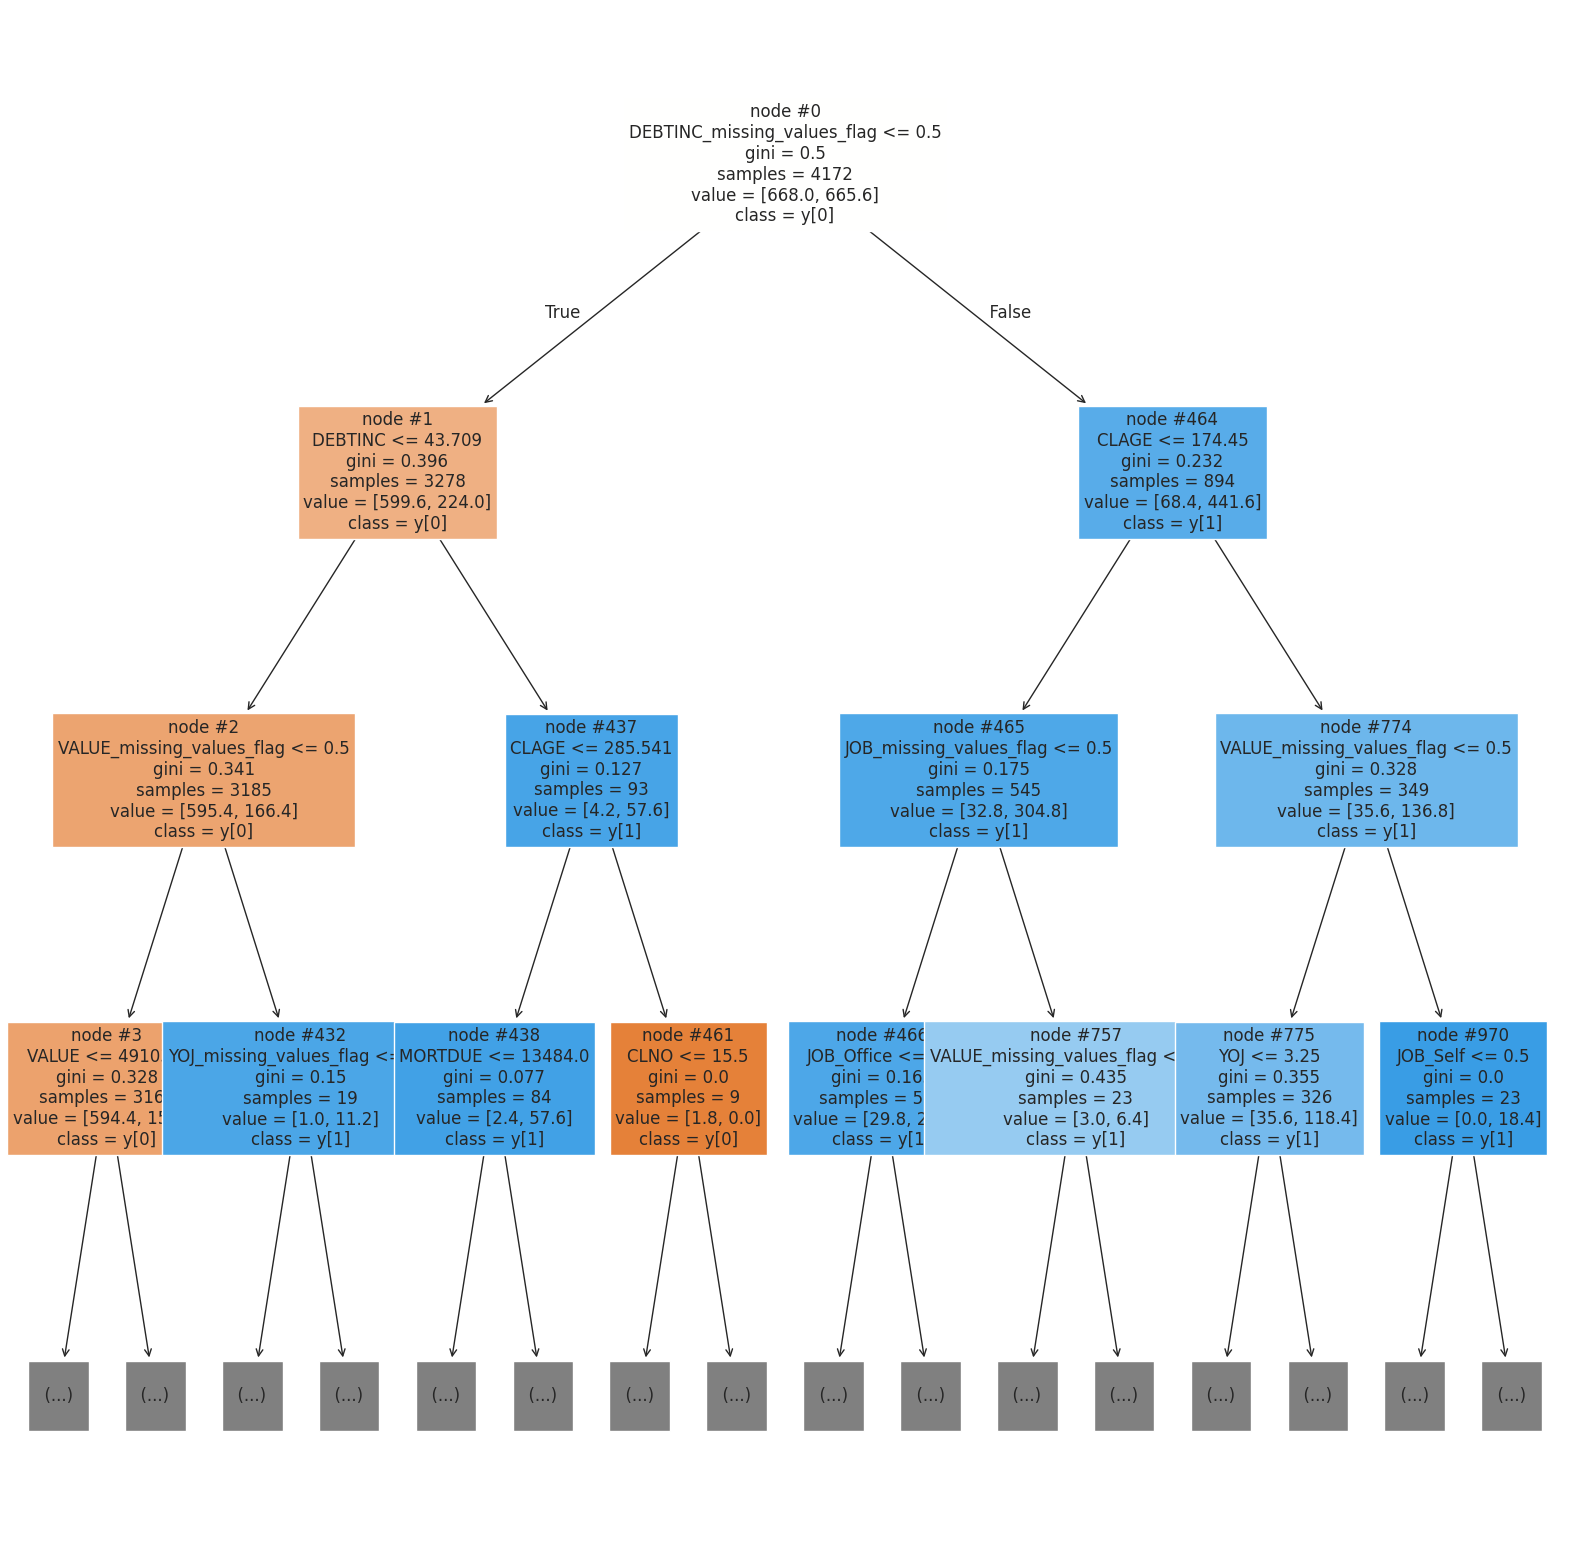

In [78]:
# Plotting the decision  tree and analyze it to build the decision rule

features = list(X.columns)

plt.figure(figsize = (20, 20))

tree.plot_tree(d_tree_tuned, max_depth = 3, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = True)

plt.show()

**Observations:**
* Blue leaves represent the defult loans, i.e., y[1] and the orange leaves represent the reapy loan, i.e., y[0].
* The more the number of observations in a leaf, the darker its color gets.

### **Building a Random Forest Classifier**

**Random Forest is a bagging algorithm where the base models are Decision Trees.** Samples are taken from the training data and on each sample a decision tree makes a prediction.

**The results from all the decision trees are combined together and the final prediction is made using voting or averaging.**

In [79]:
# Defining Random forest CLassifier

rf_estimator = RandomForestClassifier(random_state = 1)

rf_estimator.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

**Checking the performance on the train dataset**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



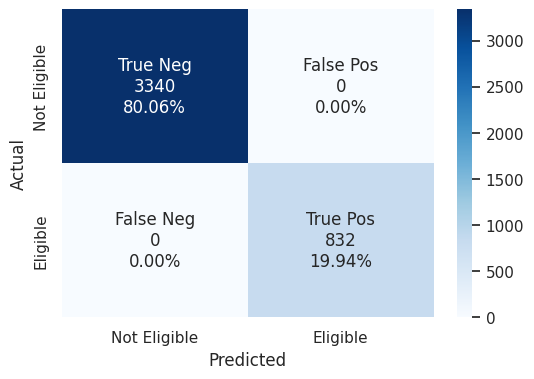

In [80]:
#Checking performance on the training data

y_pred_train_rf = rf_estimator.predict(x_train)

metrics_score(y_train, y_pred_train_rf)

**Checking the performance on the test dataset**

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1431
           1       0.79      0.67      0.72       357

    accuracy                           0.90      1788
   macro avg       0.85      0.81      0.83      1788
weighted avg       0.89      0.90      0.89      1788



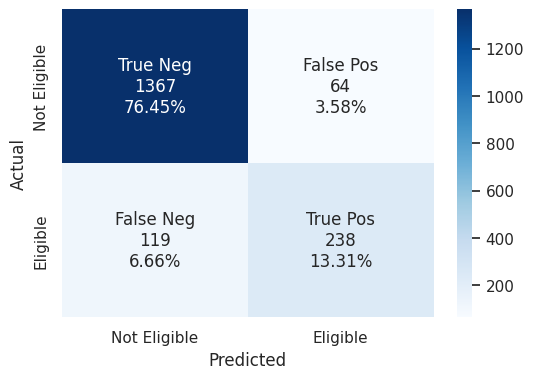

In [81]:
# Checking performance on the test data

y_pred_test_rf = rf_estimator.predict(x_test)

metrics_score(y_test, y_pred_test_rf)

In [82]:
rf_estimator_test = model_performance_classification(rf_estimator,x_test,y_test)
rf_estimator_test

,Precision,Recall,Accuracy
0,0.853999,0.810971,0.897651


**Observations:**
* The Random Forest is giving a 100% score for all metrics on the training dataset.
* The Random Forest classifier seems to be overfitting the training data. The recall on the training data is 1, while the recall on the test data is only 68% for class 1.
* Precision is good for the test data- 79%

### **Random Forest Classifier Hyperparameter Tuning**

**Build a Random Forest model with Class Weights**

In [83]:
# Defining Random Forest model with class weights class_weight={0: 0.2, 1: 0.8}
rf_estimator_balanced = RandomForestClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state = 1)

# Fitting Random Forest model
rf_estimator_balanced.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

**Checking the performance on the train dataset**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



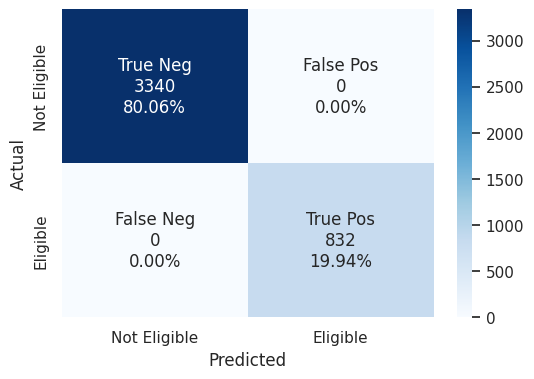

In [84]:
# Checking performance on the train data

y_pred_train_rf = rf_estimator_balanced.predict(x_train)

metrics_score(y_train, y_pred_train_rf)

**Checking the performance on the test dataset**

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1431
           1       0.77      0.64      0.70       357

    accuracy                           0.89      1788
   macro avg       0.84      0.80      0.82      1788
weighted avg       0.89      0.89      0.89      1788



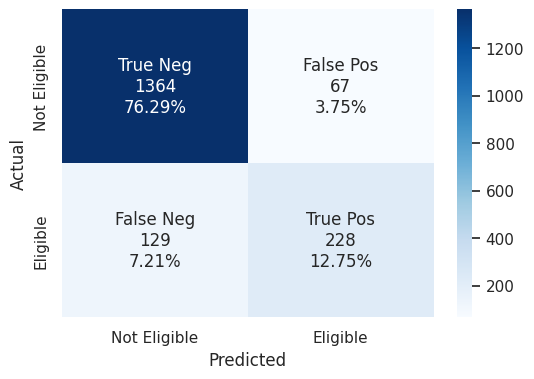

In [85]:
# Checking performance on the test data

y_pred_test_rf = rf_estimator_balanced.predict(x_test)

metrics_score(y_test, y_pred_test_rf)

In [86]:
rf_estimator_balanced_test = model_performance_classification(rf_estimator_balanced,x_test,y_test)
rf_estimator_balanced_test

,Precision,Recall,Accuracy
0,0.843239,0.795918,0.89038


**Observations:**
* The balanced random forest did not improve the model performance and also giving a 100% score for all metrics on the training dataset.
* It is is also overfitted the training data.
* The recall on the training data is 1, while the recall on the test data is only 64% for class 1 compared to 68% in the baseline model
* Precision is good for the test data- 78%

## **Tuning the Random Forest**

* Using Grid search to perform hyperparameter tuning.
* Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.
* It is an exhaustive search that is performed on the specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

In [87]:
# Choose the type of classifier
rf_estimator_tuned = RandomForestClassifier(criterion = "entropy", random_state = 7)

# Grid of parameters to choose from
parameters = {"n_estimators": [100, 110, 120],
    "max_depth": [5, 6, 7],
    "max_features": [0.8, 0.9, 1]
             }

# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(x_train, y_train)

# Set the classifier to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

In [88]:
# Fitting the best algorithm to the training data
rf_estimator_tuned.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=6, max_features=0.9,
                       random_state=7)

**Checking the performance on the train dataset**

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      3340
           1       0.77      0.67      0.72       832

    accuracy                           0.90      4172
   macro avg       0.85      0.81      0.83      4172
weighted avg       0.89      0.90      0.89      4172



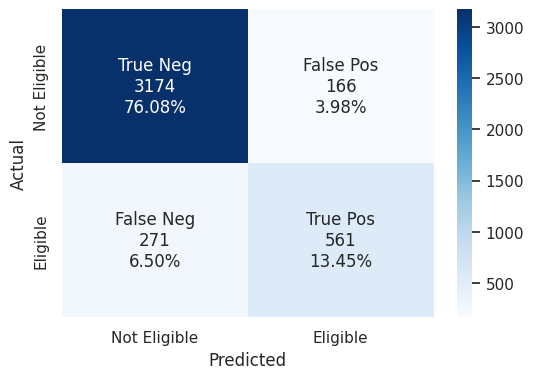

In [89]:
# Checking performance on the train data

y_pred_train_rf = rf_estimator_tuned.predict(x_train)

metrics_score(y_train, y_pred_train_rf)

**Checking the performance on the test dataset**

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1431
           1       0.76      0.61      0.68       357

    accuracy                           0.88      1788
   macro avg       0.83      0.78      0.80      1788
weighted avg       0.88      0.88      0.88      1788



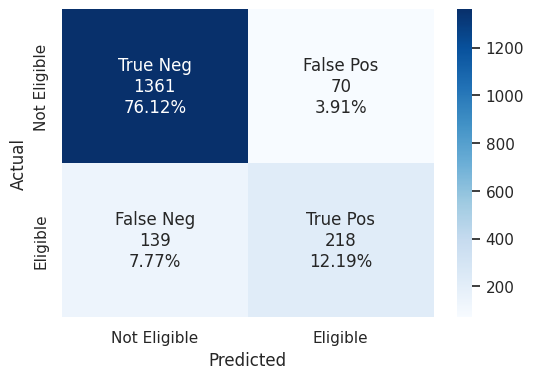

In [90]:
# Checking performance on the test data

y_pred_test_rf = rf_estimator_tuned.predict(x_test)

metrics_score(y_test, y_pred_test_rf)

In [91]:
rf_estimator_tuned_test = model_performance_classification(rf_estimator_tuned,x_test,y_test)
rf_estimator_tuned_test

,Precision,Recall,Accuracy
0,0.832139,0.780864,0.88311


**Observation:**
* The tuned random forest improves the model performance and is not giving a 100% score for all metrics on the training dataset- there is less overfitting of the training data.
* The recall on the training data is 68%, while the recall on the test data is only 61% for class 1 compared to 68% in the baseline model and 64% for the balanced random forest model.
* Precision for the test set is 75%, it has decreased compared to the baseline model and balanced model.

**Plotting the Feature importance of the tuned Random Forest**

<Axes: xlabel='Importance', ylabel='None'>

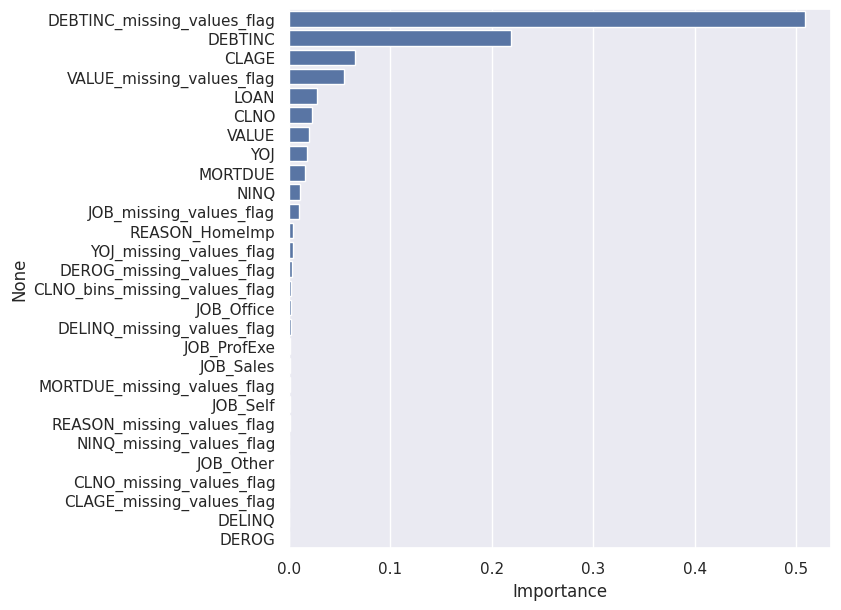

In [92]:
# Checking performace on test dataset

importances = rf_estimator_tuned.feature_importances_

columns = X.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (7, 7))

sns.barplot(x=importance_df.Importance, y=importance_df.index)

## **Building XGBoost classifier**

In [93]:
#Fitting XGBoost

xgb = XGBClassifier(random_state = 1, eval_metric = 'logloss')

# Fitting the model
xgb.fit(x_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



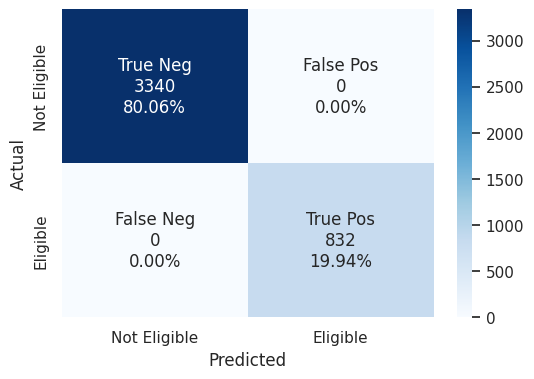

In [94]:
y_pred_train_xgb = xgb.predict(x_train)

metrics_score(y_train, y_pred_train_xgb)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1431
           1       0.82      0.66      0.73       357

    accuracy                           0.90      1788
   macro avg       0.87      0.81      0.84      1788
weighted avg       0.90      0.90      0.90      1788



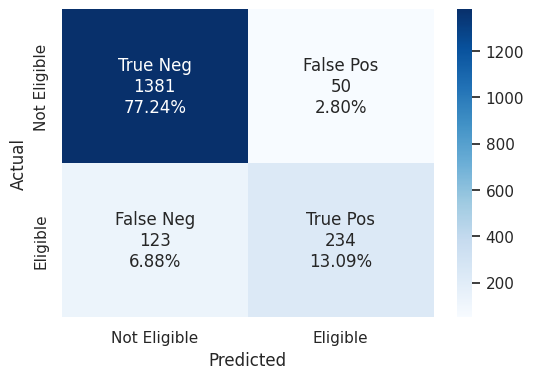

In [95]:
y_pred_test_xgb = xgb.predict(x_test)

metrics_score(y_test, y_pred_test_xgb)

In [96]:
# Model Performance on the test data
xgb_perf_test = model_performance_classification(xgb,x_test,y_test)

xgb_perf_test


,Precision,Recall,Accuracy
0,0.871081,0.810261,0.903244


**Observation:**

* The recall on the training data is 99%, while the recall on the test data is only 66% for class 1.
* Precision for the test set is 87%.
* It has highest recall, precision and accuracy compared to other models.

## **Comparing Model Performances**

In [97]:
def get_recall_score(model,flag=True,X_train=x_train,X_test=x_test):
    '''
    model : classifier to predict values of X

    '''
    a = [] # defining an empty list to store train and test results
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)
    a.append(train_recall) # adding train recall to list
    a.append(test_recall) # adding test recall to list

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))

    return a # returning the list with train and test scores

In [98]:
##  Function to calculate precision score
def get_precision_score(model,flag=True,X_train=x_train,X_test=x_test):
    '''
    model : classifier to predict values of X

    '''
    b = []  # defining an empty list to store train and test results
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)
    b.append(train_precision) # adding train precision to list
    b.append(test_precision) # adding test precision to list

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))

    return b # returning the list with train and test scores

In [99]:
##  Function to calculate accuracy score
def get_accuracy_score(model,flag=True,X_train=x_train,X_test=x_test):
    '''
    model : classifier to predict values of X

    '''
    c = [] # defining an empty list to store train and test results
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)
    c.append(train_acc) # adding train accuracy to list
    c.append(test_acc) # adding test accuracy to list

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))

    return c # returning the list with train and test scores

In [100]:
# Making the list of all the model names

models = [xgb,rf_estimator_tuned, rf_estimator_balanced, rf_estimator, d_tree_tuned, dt]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

# looping through all the models to get the accuracy,recall and precision scores
for model in models:

     # precision score
    l = get_precision_score(model,False)
    precision_train.append(l[0])
    precision_test.append(l[1])

    # accuracy score
    j = get_accuracy_score(model,False)
    acc_train.append(j[0])
    acc_test.append(j[1])

    # recall score
    k = get_recall_score(model,False)
    recall_train.append(k[0])
    recall_test.append(k[1])


In [101]:
# Mentioning the Model names in the list.
comparison_frame = pd.DataFrame({'Model':['XGBoost classifier','Tuned Random Forest', 'Balanced Random Forest','Random Forest', 'Tuned Decision Tree', 'Decision Tree'],
                                          'Train_Accuracy': acc_train,
                                          'Test_Accuracy': acc_test,
                                          'Train_Recall': recall_train,
                                          'Test_Recall': recall_test,
                                          'Train_Precision': precision_train,
                                          'Test_Precision': precision_test})
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,XGBoost classifier,1.000000,0.903244,1.000000,0.655462,1.000000,0.823944
1,Tuned Random Forest,0.895254,0.883110,0.674279,0.610644,0.771664,0.756944
2,Balanced Random Forest,1.000000,0.890380,1.000000,0.638655,1.000000,0.772881
3,Random Forest,1.000000,0.897651,1.000000,0.666667,1.000000,0.788079
4,Tuned Decision Tree,1.000000,0.850112,1.000000,0.577031,1.000000,0.637771
5,Decision Tree,1.000000,0.850112,1.000000,0.577031,1.000000,0.637771


**Total performance comparision**

In [102]:
#Compare overall precision, recall, accuracy
models_test_comp_df = pd.concat(

    [
    lg_test.T, dtree.T, dtree_tuned_test.T,rf_estimator_test.T,
    rf_estimator_balanced_test.T, rf_estimator_tuned_test.T, xgb_perf_test.T
    ],

    axis = 1,
)

models_test_comp_df.columns = [
    "Logistic regresstion model",
    "Decision Tree classifier",
    "Tuned Decision Tree classifier",
    "Random Forest classifier",
    "Balanced Random Forest classifier",
    "Tuned Random Forest classifier",
    "XGBoost classifier"
    ]



In [103]:
print("Test performance comparison:")
models_test_comp_df.T

Test performance comparison:


,Precision,Recall,Accuracy
Logistic regresstion model,0.823536,0.768960,0.877517
Decision Tree classifier,0.767350,0.747635,0.850112
Tuned Decision Tree classifier,0.767350,0.747635,0.850112
Random Forest classifier,0.853999,0.810971,0.897651
Balanced Random Forest classifier,0.843239,0.795918,0.890380
Tuned Random Forest classifier,0.832139,0.780864,0.883110
XGBoost classifier,0.871081,0.810261,0.903244


**Refined insights:**
* Models with the higher test accuracy are the **XGBoost Classifier ~.91**.
* All models overfit the training data with the exception of the **Tuned Random Forest and XGBoost Classifier**.
* The **highest recall (.82) belongs Random Forest and XGBoost Classifier**. Higher than decision tree model.
* Precision in **XGBoost Classifier models are high (~.88)**. Is also higher than Decision Tree models and Random Forest model.

## **Model Interpretability check with Shapley Values**

In [104]:
#Initialize Shap

# Need to load JS vis in the notebook
shap.initjs()


In [105]:
#Local Interpretation using SHAP (for prediction at id number 4776)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(x_train)

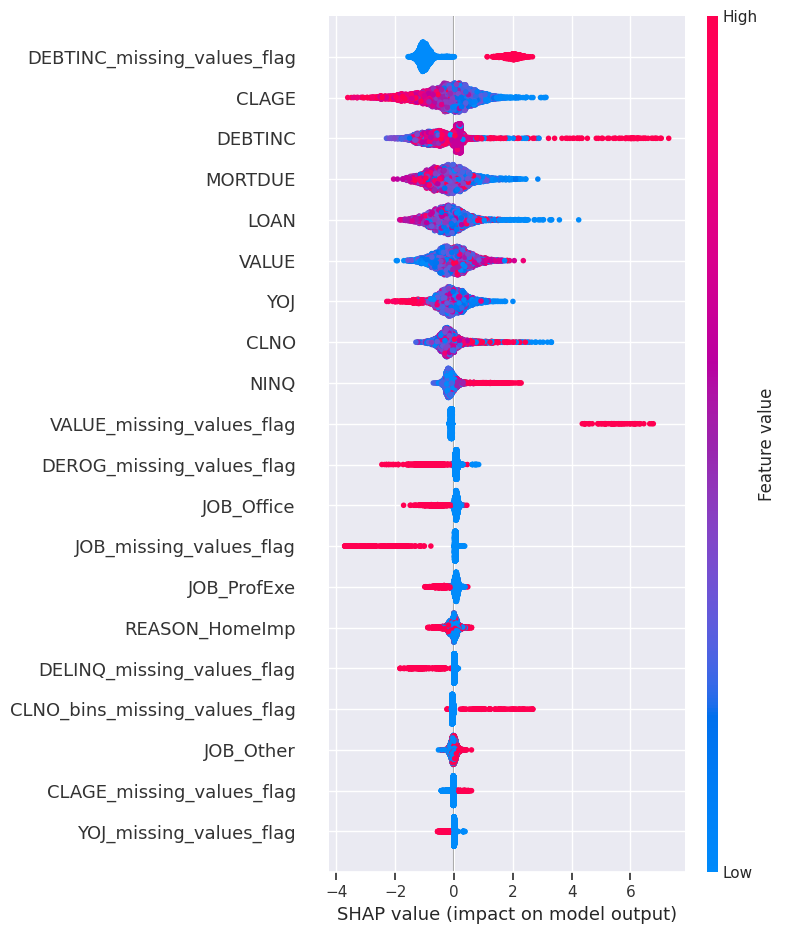

In [106]:
shap.summary_plot(shap_values, features=x_train, feature_names=x_train.columns)

**Observations:**
* High DEBTINC values are on the right side primarily because they contribute positively to identify defaulter.
* So, the prominent feature that is the most impactful in the change to default on a loan is the debt-to-income ratio.

### **Tradeoff between model performance and model interpretability**

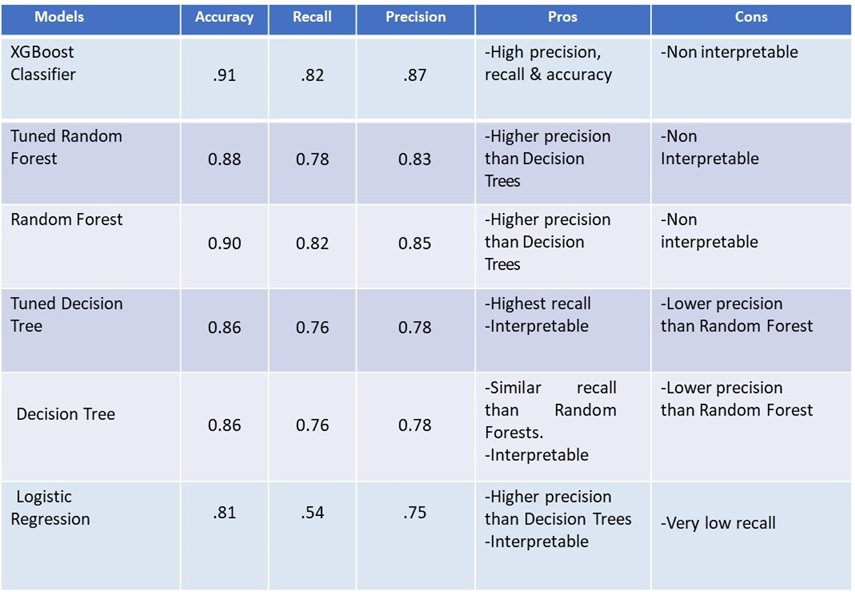

# **Executive Summary**

**Final proposed model specifications:**
* 20% of the clients in the dataset are defaulter on their loans (BAD=1). 80% of the clients have successfully repaid their loans or are not defaulter (BAD=0).
* I have tried multiple models and was able to identify the key factors involved with loan default.
* It can be seen that the financial background is more relevant than the job profile, the reason for the loan, the actual amount of the mortgage, the value of the property, and the amount of loan that was requested.
* Based on the models that were tested it is conclude that the debt-to-income ratio is the most impact feature in the chance to default on a loan.
* The bank should consider CLAGE, VALUE, LOAN, MORTDUE, and CLNO as a set of features that have a high impact on defaulting on a loan.
* The best model we have got is the XGBoost Clasifier model which is giving an average of 82% recall for class 1 on the test data, 87% precision score, and 91% accuracy- These parameters are meeting the model evolution criteria. As we know high recall & high precision model perfectly handle the class.
* While the XGBoost model often achieves higher accuracy than a single decision tree, it sacrifices the intrinsic interpretability of decision trees.
* This model is good and does not requires further tuning.
* The bank can use this model to predict clients who are likely to default on their loan.
* In future  we can test with KNN or other boosting algorithms, since we will focus on getting a high recall score.
* Bank would want Recall to be maximized, greater the Recall higher the chances of minimizing false negatives. Hence, the focus should be on increasing Recall means minimizing the false negatives or in other words identifying the true positives(i.e. Class 1)

# **Problem and solution summary**

* The prominent feature that is the most impactful in the change to default on a loan is the DEBTINC, but it is the one with the most missing data (21.3%) which is similar to the proportion of defaulted customers (20%) This emphasizes the impact of missing values on the prediction and should be communicated to the data entry team. A high debt-to-income ratio indicates that the applicant can not afford his/hers monthly mortgage payments, and having too much debt can be a sign of missing a payment or defaulting on the loan. The bank should consider this as a top feature to consider while processing a loan request.
* Prediction and explainable models are combined to predict the personal loan defaults in our study. The predictive ability of machine learning models will be further improved, and their complexity will also increase. Explainable models can effectively help with model recognition and judging whether the model is consistent with reality. In the future, other explainable models can also be applied to estimate the overall influence of the features used.

# **Recommendations for implementation**

* Check the possibility to create an alternative business process to manage and take decisions on those clients with no Debt/Income ratio available.
* Explore other machine learning techniques such as engineering features, dropping columns, different method for handling missing value with new algorithms like other Bosting algorithms, support vector machine, KNN, neural networks.
* Create a pilot test with the new model and compare the results with the current manual process before completing the transition to the new model.
* Consider using balancing techniques, such as ROSE (Random Over Sampling Examples) and SMOTE (Synthetic Minority Oversampling Technique) or under sampling methods, to generate synthetic data. These methods have achieved good results on unbalanced datasets.


**Risk and Challenges:**
* The major risk associated with developing a product that meets the needs of both consumer and business.
* A big challenge is to increase the current incomes with the new model.
*	There will be an emotional challenge to launch new technology while supporting old ones. User will react with fear, they don’t want to adopt with the new technology
*	Cost will be related to train the user with new system.


## 🏦 **Business Recommendations**

Based on the analysis, the bank should:

**1. Strengthen Credit Screening**
- Prioritize applicants with strong credit history and lower DTI.

**2. Risk-Based Pricing**
- Adjust interest rates based on predicted risk score.

**3. Early Warning Monitoring**
- Flag high-risk borrowers for proactive follow-up.

**4. Portfolio Management**
- Use risk segmentation to manage exposure across borrower groups.